# Entrenamiento de Modelos — MFCCs Aumentados Diarizados

Versión del notebook que utiliza los datos diarizados aumentados ( / ).

In [88]:
import pickle
import numpy as np
import pandas as pd
import mlflow

#Tablas y Gráficos
import matplotlib.pyplot as plt
import seaborn as sns

#Preprocesado
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.pipeline import Pipeline

#Modelos
import joblib
from sklearn.base import clone
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_auc_score, roc_curve, auc, classification_report
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix
from sklearn.model_selection import GridSearchCV
from sklearn.feature_selection import SelectKBest, f_classif, VarianceThreshold
from sklearn.multioutput import MultiOutputClassifier
from sklearn.model_selection import PredefinedSplit
from lightgbm import LGBMClassifier
from sklearn.neighbors import KNeighborsClassifier

In [2]:
mlflow.set_tracking_uri("sqlite:///../resultados/resultados_voces.db")
mlflow.set_experiment("Clasificacion_Modelos_Clasicos_Notebooks")

<Experiment: artifact_location='file:///C:/Users/pedro/git/RepositorioInvestigacionTFG/notebooks/mlruns/3', creation_time=1781536250318, effective_trace_archival_retention=None, experiment_id='3', last_update_time=1781536250318, lifecycle_stage='active', name='Clasificacion_Modelos_Clasicos_Notebooks', tags={}, trace_location=None, workspace='default'>

In [3]:
ruta_train = '../datos_entrenamiento/train_mfcc_chunked_aumentado_diarizado.pkl'
ruta_test = '../datos_entrenamiento/test_mfcc_chunked_aumentado_diarizado.pkl'

datos_train = pickle.load(open(ruta_train, 'rb'))
datos_test = pickle.load(open(ruta_test, 'rb'))

df_train = pd.DataFrame(datos_train)
df_test = pd.DataFrame(datos_test)

print("Forma del Dataset de entrenamiento:", df_train.shape)
print()
print("Encontrar datos nulos --->", df_train.isnull().sum())
print()
print("¿Hay valores nulos?: ", df_train.isnull().any().any())

print("Forma del Dataset de test:", df_test.shape)
print()
print("Encontrar datos nulos --->", df_test.isnull().sum())
print()
print("¿Hay valores nulos?: ", df_test.isnull().any().any())

Forma del Dataset de entrenamiento: (1768, 5)

Encontrar datos nulos ---> nombre_archivo    0
mfccs             0
caja_toracica     0
grupo             0
fold              0
dtype: int64

¿Hay valores nulos?:  False
Forma del Dataset de test: (100, 5)

Encontrar datos nulos ---> nombre_archivo    0
mfccs             0
caja_toracica     0
grupo             0
fold              0
dtype: int64

¿Hay valores nulos?:  False


En este caso, como sí hemos aplicado chunking de manera previa, todas las entradas de nuestro dataframe tendrán el mismo número de coeficientes. Es decir, estamos trabajando con un dataframe normalizado en cuanto a longitud de datos se refiere.

Esto nos permite trabajar de manera directa en la extracción de características en base a los coeficientes de mel, para así pasar directamente al entrenamiento de modelos. Los modelos que vamos a entrenar (RF, SVM y GB) requieren que todas las muestras del conjunto de datos tengan exactamente la misma dimensionalidad de entrada, y esto es algo que tenemos de base en este caso.

## Extracción Características

Al igual que en el notebook anterior, necesitamos transformar las matrices MFCC (30 × 1001) en vectores unidimensionales para poder trabajar con modelos clásicos de ML. Aplicaremos las dos mismas estrategias:

- **Mean+Std pooling**: comprime cada muestra en 60 características (30 medias + 30 desviaciones típicas). Mitiga la maldición de la dimensionalidad y es la representación más robusta para datasets de tamaño moderado.
- **Flatten completo**: genera ~30.030 características por muestra.

In [4]:
df_train.head()

,nombre_archivo,mfccs,caja_toracica,grupo,fold
0,Nueva grabación 35_chunk000_original.wav,"[[-509.01492, -486.2265, -471.39362, -478.1155...",Mixto,Oxigeno Bajo Flujo,1
1,Nueva grabación 35_chunk000_noise.wav,"[[-438.88876, -400.33658, -389.66284, -400.635...",Mixto,Oxigeno Bajo Flujo,1
2,Nueva grabación 35_chunk000_pitch.wav,"[[-505.59192, -474.11838, -464.56128, -457.322...",Mixto,Oxigeno Bajo Flujo,1
3,Nueva grabación 35_chunk000_stretch.wav,"[[-516.53595, -492.094, -474.74338, -478.84897...",Mixto,Oxigeno Bajo Flujo,1
4,Nueva grabación 35_chunk001_original.wav,"[[-458.3255, -471.12286, -474.46725, -450.0719...",Mixto,Oxigeno Bajo Flujo,1


In [5]:
#Funcion transformar datasets:
def generar_datasets_aplanados(df):
      metadatos = df[['nombre_archivo', 'grupo', 'caja_toracica', 'fold']]
      n_mfcc = df['mfccs'].iloc[0].shape[0]

      # Dataset 1: Mean + Std (60 features)
      medias = pd.DataFrame(
          df['mfccs'].apply(lambda x: np.mean(x, axis=1)).tolist(),
          columns=[f'mfcc_media_{i+1}' for i in range(n_mfcc)],
          index=df.index
      )
      stds = pd.DataFrame(
          df['mfccs'].apply(lambda x: np.std(x, axis=1)).tolist(),
          columns=[f'mfcc_std_{i+1}' for i in range(n_mfcc)],
          index=df.index
      )
      df_pooling = pd.concat([metadatos, medias, stds], axis=1)

      # Dataset 2: Flatten completo (~30k features)
      df_flatten_features = pd.DataFrame(
          df['mfccs'].apply(lambda x: x.flatten()).tolist(),
          index=df.index
      )
      df_flatten = pd.concat([metadatos, df_flatten_features], axis=1)

      return df_pooling, df_flatten

df_train_pool, df_train_flat = generar_datasets_aplanados(df_train)
df_test_pool, df_test_flat = generar_datasets_aplanados(df_test)

In [6]:
print(f"Shape Train Plano: {df_train_flat.shape} + Shape Test Plano: {df_test_flat.shape}")
print(f"Shape Train Pooleado: {df_train_pool.shape} + Shape Test Pooleado: {df_test_pool.shape}")

Shape Train Plano: (1768, 30034) + Shape Test Plano: (100, 30034)
Shape Train Pooleado: (1768, 64) + Shape Test Pooleado: (100, 64)


### Extracción Características + Modelos DF_FLAT

Comenzaremos aplicando una reducción agresiva de características. Sin embargo, teniendo en cuenta la elevada dimensionalidad de las características, no podemos simplemente pasar a calcular la matriz de correlación, ya que supondría un coste computacional extremadamente elevado.

Sin embargo, podemos aplicar otra técnica que si nos pueda permitir reducir las características de manera agresiva, que es variance_threshold. Esta función permite eliminar todas aquellas características que tengan un valor menor o igual de varianza al que nosotros establezcamos.

In [7]:
columnas_a_quitar_pca = ['nombre_archivo', 'grupo', 'caja_toracica', 'fold']

scaler_pca = StandardScaler()
subset_X = df_train_flat.drop(columns=columnas_a_quitar_pca)
df_train_flat_transformed = scaler_pca.fit_transform(subset_X)

pca_full = PCA()
pca_full.fit_transform(df_train_flat_transformed)

cumulative_variance = np.cumsum(pca_full.explained_variance_ratio_)
print(cumulative_variance)

[0.03018641 0.05575683 0.07664747 ... 0.9999873  1.0000001  1.0000001 ]


Como podemos observar, ni aplicando un threshold del 10% podemos reducir la dimensionalidad. Lo mejor puede ser pasar directamente a aplicar PCA y SelectKBest, en dos experimentos distintos.

#### PCA en FLAT

En este caso, iremos viendo con cuantas características nos podemos quedar con cada % de varianza, y eligiremos el numero que mejor nos venga.

In [8]:
#Numero de predictores con 95%
n_components_base = df_train_flat.drop(columns = columnas_a_quitar_pca).shape[1]
print(f"Nº Componentes de base: {n_components_base}")
n_components_95 = np.argmax(cumulative_variance >= 0.95)
print(f"Componentes necesarios para explicar el 95%: {n_components_95}")

#Numero de predictores con 90%
n_components_90 = np.argmax(cumulative_variance >= 0.90)
print(f"Componentes necesarios para explicar el 90%: {n_components_90}")

#Numero de predictores con 88%
n_components_88 = np.argmax(cumulative_variance >= 0.88)
print(f"Componentes necesarios para explicar el 88%: {n_components_88}")

#Numero de predictores con 85%
n_components_85 = np.argmax(cumulative_variance >= 0.85)
print(f"Componentes necesarios para explicar el 85%: {n_components_85}")

#Numero de predictores con 80%
n_components_80 = np.argmax(cumulative_variance >= 0.80)
print(f"Componentes necesarios para explicar el 80%: {n_components_80}")

#Numero de predictores con 75%
n_components_75 = np.argmax(cumulative_variance >= 0.75)
print(f"Componentes necesarios para explicar el 75%: {n_components_75}")

Nº Componentes de base: 30030
Componentes necesarios para explicar el 95%: 1183
Componentes necesarios para explicar el 90%: 976
Componentes necesarios para explicar el 88%: 907
Componentes necesarios para explicar el 85%: 814
Componentes necesarios para explicar el 80%: 682
Componentes necesarios para explicar el 75%: 573


Podemos observar como, pese a reducir en cierta medida el % de varianza, nos seguimos encontrando con un gran número de predictores. Lo idóneo, teniendo en cuenta la cantidad de muestras (1768), sería intentar reducir el nº de componentes a unos 125-150 predictores. Seguirá aun así siendo una gran cantidad de predictores, que puede que lleve a cierto sobreentrenamiento, o en un mejor caso, solo nos lleve a un entrenamiento con elevado coste computacional, sin embargo, este número de características representa una relación muestras/predictores que puede ser útil.

Vamos a observar con que % de varianza nos debemos quedar si queremos quedarnos con 125 o 150 componentes principales:

In [9]:
print(f"Varianza explicada con 125 componentes: {cumulative_variance[125]:.4f}")

print(f"Varianza explicada con 150 componentes: {cumulative_variance[150]:.4f}")

Varianza explicada con 125 componentes: 0.3967
Varianza explicada con 150 componentes: 0.4289


Aun que perdamos bastante información, vamos a quedarnos con este numero de componentes (más bien, con el numero de componentes que representan el 45% de la varianza).

In [10]:
X_train_num_pca = df_train_flat.drop(columns=columnas_a_quitar_pca)
X_test_num_pca = df_test_flat.drop(columns=columnas_a_quitar_pca)

scaler_flat = StandardScaler()
X_train_scaled_pca = scaler_flat.fit_transform(X_train_num_pca)
X_test_scaled_pca = scaler_flat.transform(X_test_num_pca)

n_componentes = 0.45 #Nos quedamos con el 45% de la varianza
pca = PCA(n_components=n_componentes, random_state=42)
X_train_pca_flat = pca.fit_transform(X_train_scaled_pca)
X_test_pca_flat = pca.transform(X_test_scaled_pca)

n_componentes_finales = X_train_pca_flat.shape[1]
print(f"El PCA ha seleccionado {n_componentes_finales} componentes principales.")

df_pca_train_flat = pd.DataFrame(
    X_train_pca_flat,
    columns=[f'MFCC_flat_pca{i+1}' for i in range(n_componentes_finales)],
    index=df_train_flat.index
)
df_train_flat_1 = pd.concat([df_train_flat[columnas_a_quitar_pca], df_pca_train_flat], axis=1)

df_pca_test_flat = pd.DataFrame(
    X_test_pca_flat,
    columns=[f'MFCC_flat_pca{i+1}' for i in range(n_componentes_finales)],
    index=df_test_flat.index
)
df_test_flat_1 = pd.concat([df_test_flat[columnas_a_quitar_pca], df_pca_test_flat], axis=1)

print("\nVista previa del conjunto de ENTRENAMIENTO post-pca:")
display(df_train_flat_1.head())

El PCA ha seleccionado 169 componentes principales.

Vista previa del conjunto de ENTRENAMIENTO post-pca:


,nombre_archivo,grupo,caja_toracica,fold,MFCC_flat_pca1,MFCC_flat_pca2,MFCC_flat_pca3,MFCC_flat_pca4,MFCC_flat_pca5,MFCC_flat_pca6,...,MFCC_flat_pca160,MFCC_flat_pca161,MFCC_flat_pca162,MFCC_flat_pca163,MFCC_flat_pca164,MFCC_flat_pca165,MFCC_flat_pca166,MFCC_flat_pca167,MFCC_flat_pca168,MFCC_flat_pca169
0,Nueva grabación 35_chunk000_original.wav,Oxigeno Bajo Flujo,Mixto,1,1.403120,11.818148,-25.477968,6.150051,12.601660,14.118361,...,-7.724813,-2.070486,-8.028156,-0.648304,-4.944509,8.655043,-1.841909,4.247753,7.027108,-0.479669
1,Nueva grabación 35_chunk000_noise.wav,Oxigeno Bajo Flujo,Mixto,1,-39.362648,0.581221,-36.585255,6.601433,5.545866,15.919083,...,-5.025447,-1.033723,-7.005903,-1.283131,-3.966194,8.311903,-0.293399,4.389431,4.175663,0.320780
2,Nueva grabación 35_chunk000_pitch.wav,Oxigeno Bajo Flujo,Mixto,1,2.040362,18.209667,-24.076815,1.892341,12.692274,16.673740,...,-4.900434,2.305598,-4.429152,5.614604,5.040562,-2.075406,-1.012035,5.258912,4.007135,1.932429
3,Nueva grabación 35_chunk000_stretch.wav,Oxigeno Bajo Flujo,Mixto,1,12.820142,18.174250,-39.284348,2.495595,-10.915717,-1.057009,...,-7.229088,-1.033713,-1.864201,-0.111551,0.791150,-1.965939,-0.922241,0.233289,3.769421,1.095814
4,Nueva grabación 35_chunk001_original.wav,Oxigeno Bajo Flujo,Mixto,1,23.582434,22.091675,-15.714938,2.107284,16.240633,8.443452,...,-5.269526,3.839381,-0.749471,1.115191,2.218011,4.602930,-6.768407,-4.147269,-3.784678,5.025271


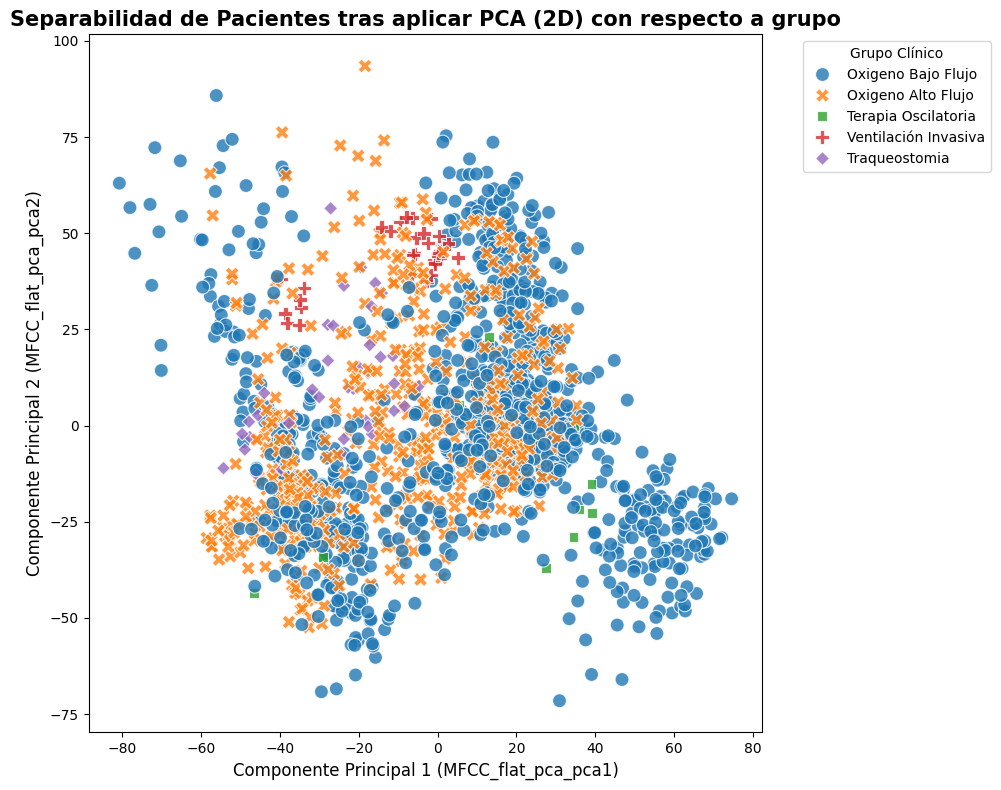

In [11]:
#Breve análisis visual de los datos con PCA.
plt.figure(figsize=(10, 8))

#Elegimos los 2 primeros Embedding por que son los que mas información aportan
sns.scatterplot(
    data=df_train_flat_1, 
    x='MFCC_flat_pca1', 
    y='MFCC_flat_pca2', 
    hue='grupo', 
    style='grupo', 
    s=100,         
    alpha=0.8      
)

plt.title('Separabilidad de Pacientes tras aplicar PCA (2D) con respecto a grupo', fontsize=15, fontweight='bold')
plt.xlabel('Componente Principal 1 (MFCC_flat_pca_pca1)', fontsize=12)
plt.ylabel('Componente Principal 2 (MFCC_flat_pca_pca2)', fontsize=12)

plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', title='Grupo Clínico')

plt.tight_layout()
plt.show()

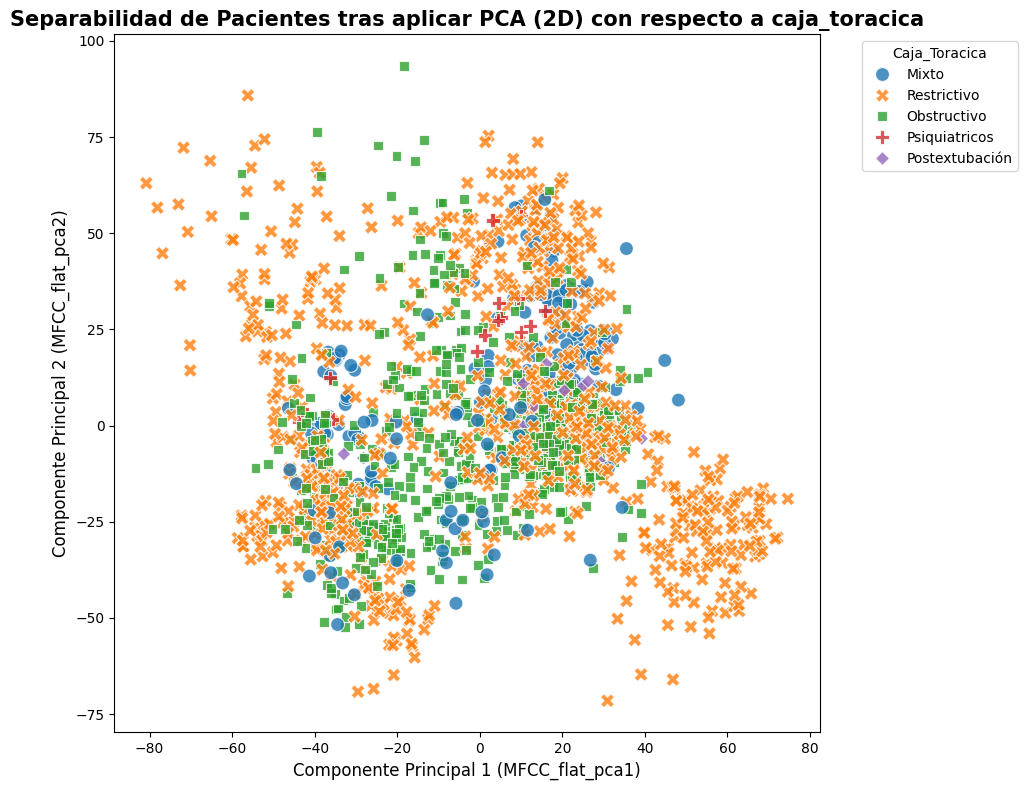

In [12]:
#Breve análisis visual de los datos con PCA.
plt.figure(figsize=(10, 8))

#Elegimos los 2 primeros Embedding por que son los que mas información aportan
sns.scatterplot(
    data=df_train_flat_1, 
    x='MFCC_flat_pca1', 
    y='MFCC_flat_pca2', 
    hue='caja_toracica', 
    style='caja_toracica', 
    s=100,         
    alpha=0.8      
)

plt.title('Separabilidad de Pacientes tras aplicar PCA (2D) con respecto a caja_toracica', fontsize=15, fontweight='bold')
plt.xlabel('Componente Principal 1 (MFCC_flat_pca1)', fontsize=12)
plt.ylabel('Componente Principal 2 (MFCC_flat_pca2)', fontsize=12)

plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', title='Caja_Toracica')

plt.tight_layout()
plt.show()

Con estos gráficos de dispersión buscamos representar cada chunk como un punto en un gráfico de coordenadas, teniendo en cuenta los valores de MFCC_flat_pca1 y MFCC_flat_pca2. Los 2 primeros componentes principales de un PCA son aquellas que agrupan mayor cantidad de información (varianza). En ambos gráficos podemos observar que no hay nubes de puntos claramente separadas.

En este caso podemos observar que los datos presentan una extrema complejidad acústica. El nivel de solapamiento entre las clases de mayor volumen confirma que los diferentes grupos y patologías no son linealmente separables utilizando únicamente sus dos componentes de mayor varianza.

Sin embargo, esta misma densidad de puntos contiene patrones subyacentes valiosos. Aunque a nivel global observemos una gran mezcla, la concentración de datos sugiere que en el espacio multidimensional del PCA existen vecindarios muy poblados de chunks. La existencia de estas densidades locales justifica el uso, de nuevo, de modelos como K-Nearest Neighbors (KNN).

#### Entrenamiento Modelos Flat con PCA

Para este caso aplicaremos modelos básicos como SVM, RF o GB sobre los datos procesados de Embedding con pca (Primera ruta). Como hemos observado, los datos de momento no presentan mucha correlación con respecto al grupo o a la caja_toracica (patología). Esperamos que para este primer análisis no obtener resultados excesivamente excelentes.

In [13]:
from sklearn.metrics import make_scorer
scoring_cv = {
    'accuracy':    make_scorer(accuracy_score),
    'f1_macro':    make_scorer(f1_score, average='macro',    zero_division=0),
    'f1_weighted': make_scorer(f1_score, average='weighted', zero_division=0),
}

def evaluar_modelo_pca_flat(grid_grupo, grid_caja, nombre_modelo):    
    print(f"Mejores Hiperparámetros Grupo: {grid_grupo.best_params_}")
    print(f"Mejores Hiperparámetros Caja:  {grid_caja.best_params_}")
    idx_g = grid_grupo.best_index_
    idx_c = grid_caja.best_index_
    acc_g = grid_grupo.cv_results_['mean_test_accuracy'][idx_g]
    f1_mac_g = grid_grupo.cv_results_['mean_test_f1_macro'][idx_g]
    f1_w_g = grid_grupo.cv_results_['mean_test_f1_weighted'][idx_g]
    std_g = grid_grupo.cv_results_['std_test_f1_macro'][idx_g]
    acc_c = grid_caja.cv_results_['mean_test_accuracy'][idx_c]
    f1_mac_c = grid_caja.cv_results_['mean_test_f1_macro'][idx_c]
    f1_w_c = grid_caja.cv_results_['mean_test_f1_weighted'][idx_c]
    std_c = grid_caja.cv_results_['std_test_f1_macro'][idx_c]
    print(f"[CV] Grupo - Acc: {acc_g*100:.2f}% | F1-Macro: {f1_mac_g*100:.2f}% (+/-{std_g*100:.2f}%) | F1-Weighted: {f1_w_g*100:.2f}%")
    print(f"[CV] Caja  - Acc: {acc_c*100:.2f}% | F1-Macro: {f1_mac_c*100:.2f}% (+/-{std_c*100:.2f}%) | F1-Weighted: {f1_w_c*100:.2f}%")
    mlflow.log_metric("grupo_acc_cv", acc_g)
    mlflow.log_metric("grupo_f1_macro_cv", f1_mac_g)
    mlflow.log_metric("grupo_f1_weighted_cv", f1_w_g)
    mlflow.log_metric("caja_acc_cv", acc_c)
    mlflow.log_metric("caja_f1_macro_cv", f1_mac_c)
    mlflow.log_metric("caja_f1_weighted_cv", f1_w_c)
    for key, value in grid_grupo.best_params_.items():
        mlflow.log_param(f"grupo_best_{key}", value)
    for key, value in grid_caja.best_params_.items():
        mlflow.log_param(f"caja_best_{key}", value)

In [14]:
columnas_pca = [col for col in df_train_flat_1.columns if 'pca' in col]

X_train_model = df_train_flat_1[columnas_pca]
X_test_model = df_test_flat_1[columnas_pca]

y_train_grupo = df_train_flat_1['grupo']
y_test_grupo = df_test_flat_1['grupo']

y_train_caja = df_train_flat_1['caja_toracica']
y_test_caja = df_test_flat_1['caja_toracica']

In [15]:
folds_oficiales = df_train_flat_1['fold'].values
ps = PredefinedSplit(test_fold=folds_oficiales)

In [16]:
#Tunearemos los hiperparámetros con las ejecuciones y veremos cuales son las mejores configuraciones para cada modelo. Para cada uno haremos que la ejecución inicial sea con 
#hiperparámetros base de la documentación

#Comenzamos con RF: comenzaremos utilizando sus hiperparámetros de base:
#https://scikit-learn.org/stable/modules/generated/sklearn.ensemble.RandomForestClassifier.html
param_grid_rf = {
    'n_estimators': [100],      
    'max_depth': [None],        
    'min_samples_split': [2],   
    'min_samples_leaf': [1],    
    'max_features': ['sqrt'], 
    'bootstrap': [True]         
}

with mlflow.start_run(run_name="RF_Chunking_Diarizado_Aumentado_flat_pca_default"):

    mlflow.set_tag("tipo_dataset", "Chunking_Diarizado_Aumentado_flat") 
    mlflow.set_tag("modelo", "Random Forest")
    mlflow.set_tag("feature_extraction", "PCA")
    
    #Entrenamos para cada objetivo
    rf_base_grupo = RandomForestClassifier(class_weight='balanced', random_state=42)
    grid_rf_grupo = GridSearchCV(rf_base_grupo, param_grid_rf, scoring=scoring_cv, refit='f1_macro', cv=ps, n_jobs=-1)
    grid_rf_grupo.fit(X_train_model, y_train_grupo)
    
    rf_base_caja = RandomForestClassifier(class_weight='balanced', random_state=42)
    grid_rf_caja = GridSearchCV(rf_base_caja, param_grid_rf, scoring=scoring_cv, refit='f1_macro', cv=ps, n_jobs=-1)
    grid_rf_caja.fit(X_train_model, y_train_caja)
    
    evaluar_modelo_pca_flat(grid_rf_grupo, grid_rf_caja, "Random Forest - PCA - Flat - Aumentado Diarizado")

Mejores Hiperparámetros Grupo: {'bootstrap': True, 'max_depth': None, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 100}
Mejores Hiperparámetros Caja:  {'bootstrap': True, 'max_depth': None, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 100}
[CV] Grupo - Acc: 64.49% | F1-Macro: 29.99% (+/-11.37%) | F1-Weighted: 54.06%
[CV] Caja  - Acc: 39.72% | F1-Macro: 21.53% (+/-6.31%) | F1-Weighted: 35.38%


In [17]:
param_grid_rf_1 = {
    'n_estimators': [100, 150],      
    'max_depth': [None, 10, 20],        
    'min_samples_split': [2, 5],   
    'min_samples_leaf': [1, 2],    
    'max_features': ['sqrt'], 
    'bootstrap': [True]         
}


#Entrenamos para cada objetivo
with mlflow.start_run(run_name="RF_Chunking_Diarizado_Aumentado_flat_pca_tune1"):

    mlflow.set_tag("tipo_dataset", "Chunking_Diarizado_Aumentado_flat") 
    mlflow.set_tag("modelo", "Random Forest")
    mlflow.set_tag("feature_extraction", "PCA")
    
    #Entrenamos para cada objetivo
    rf_base_grupo = RandomForestClassifier(class_weight='balanced', random_state=42)
    grid_rf_grupo = GridSearchCV(rf_base_grupo, param_grid_rf_1, scoring=scoring_cv, refit='f1_macro', cv=ps, n_jobs=-1)
    grid_rf_grupo.fit(X_train_model, y_train_grupo)
    
    rf_base_caja = RandomForestClassifier(class_weight='balanced', random_state=42)
    grid_rf_caja = GridSearchCV(rf_base_caja, param_grid_rf_1, scoring=scoring_cv, refit='f1_macro', cv=ps, n_jobs=-1)
    grid_rf_caja.fit(X_train_model, y_train_caja)
    
    evaluar_modelo_pca_flat(grid_rf_grupo, grid_rf_caja, "Random Forest - PCA - Flat - Aumentado Diarizado")


Mejores Hiperparámetros Grupo: {'bootstrap': True, 'max_depth': 10, 'max_features': 'sqrt', 'min_samples_leaf': 2, 'min_samples_split': 2, 'n_estimators': 150}
Mejores Hiperparámetros Caja:  {'bootstrap': True, 'max_depth': 10, 'max_features': 'sqrt', 'min_samples_leaf': 2, 'min_samples_split': 2, 'n_estimators': 100}
[CV] Grupo - Acc: 63.91% | F1-Macro: 33.78% (+/-14.37%) | F1-Weighted: 56.59%
[CV] Caja  - Acc: 40.53% | F1-Macro: 22.85% (+/-6.60%) | F1-Weighted: 36.54%


In [19]:
param_grid_rf_2_grupo_flat_pca = {
    'n_estimators': [150, 200],      
    'max_depth': [None, 10],        
    'min_samples_split': [2, 5],   
    'min_samples_leaf': [2, 6],    
    'max_features': ['sqrt'], 
    'bootstrap': [True]         
}

param_grid_rf_2_caja_flat_pca = {
    'n_estimators': [100, 200],      
    'max_depth': [None, 10],        
    'min_samples_split': [5, 10],   
    'min_samples_leaf': [1, 2],    
    'max_features': ['sqrt'], 
    'bootstrap': [True]         
}


#Entrenamos para cada objetivo
with mlflow.start_run(run_name="RF_Chunking_Diarizado_Aumentado_flat_pca_tune2"):

    mlflow.set_tag("tipo_dataset", "Chunking_Diarizado_Aumentado_flat") 
    mlflow.set_tag("modelo", "Random Forest")
    mlflow.set_tag("feature_extraction", "PCA")
    
    #Entrenamos para cada objetivo
    rf_base_grupo = RandomForestClassifier(class_weight='balanced', random_state=42)
    grid_rf_grupo = GridSearchCV(rf_base_grupo, param_grid_rf_2_grupo_flat_pca, scoring=scoring_cv, refit='f1_macro', cv=ps, n_jobs=-1)
    grid_rf_grupo.fit(X_train_model, y_train_grupo)
    
    rf_base_caja = RandomForestClassifier(class_weight='balanced', random_state=42)
    grid_rf_caja = GridSearchCV(rf_base_caja, param_grid_rf_2_caja_flat_pca, scoring=scoring_cv, refit='f1_macro', cv=ps, n_jobs=-1)
    grid_rf_caja.fit(X_train_model, y_train_caja)
    
    evaluar_modelo_pca_flat(grid_rf_grupo, grid_rf_caja, "Random Forest - PCA - Flat - Aumentado Diarizado")

Mejores Hiperparámetros Grupo: {'bootstrap': True, 'max_depth': 10, 'max_features': 'sqrt', 'min_samples_leaf': 6, 'min_samples_split': 2, 'n_estimators': 150}
Mejores Hiperparámetros Caja:  {'bootstrap': True, 'max_depth': 10, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'min_samples_split': 10, 'n_estimators': 100}
[CV] Grupo - Acc: 63.59% | F1-Macro: 36.04% (+/-17.69%) | F1-Weighted: 57.71%
[CV] Caja  - Acc: 40.94% | F1-Macro: 22.25% (+/-5.72%) | F1-Weighted: 36.94%


In [20]:
param_grid_rf_3_grupo_flat_pca = {
    'n_estimators': [150, 300],      
    'max_depth': [None, 10],        
    'min_samples_split': [2],   
    'min_samples_leaf': [6, 8],    
    'max_features': ['sqrt'], 
    'bootstrap': [True]         
}

param_grid_rf_3_caja_flat_pca = {
    'n_estimators': [100, 300],      
    'max_depth': [None],        
    'min_samples_split': [10, 15],   
    'min_samples_leaf': [1, 2],    
    'max_features': ['sqrt'], 
    'bootstrap': [True]         
}


#Entrenamos para cada objetivo
with mlflow.start_run(run_name="RF_Chunking_Diarizado_Aumentado_flat_pca_tune3"):

    mlflow.set_tag("tipo_dataset", "Chunking_Diarizado_Aumentado_flat") 
    mlflow.set_tag("modelo", "Random Forest")
    mlflow.set_tag("feature_extraction", "PCA")
    
    #Entrenamos para cada objetivo
    rf_base_grupo = RandomForestClassifier(class_weight='balanced', random_state=42)
    grid_rf_grupo = GridSearchCV(rf_base_grupo, param_grid_rf_3_grupo_flat_pca, scoring=scoring_cv, refit='f1_macro', cv=ps, n_jobs=-1)
    grid_rf_grupo.fit(X_train_model, y_train_grupo)
    
    rf_base_caja = RandomForestClassifier(class_weight='balanced', random_state=42)
    grid_rf_caja = GridSearchCV(rf_base_caja, param_grid_rf_3_caja_flat_pca, scoring=scoring_cv, refit='f1_macro', cv=ps, n_jobs=-1)
    grid_rf_caja.fit(X_train_model, y_train_caja)
    
    evaluar_modelo_pca_flat(grid_rf_grupo, grid_rf_caja, "Random Forest - PCA - Flat - Aumentado Diarizado")

Mejores Hiperparámetros Grupo: {'bootstrap': True, 'max_depth': 10, 'max_features': 'sqrt', 'min_samples_leaf': 8, 'min_samples_split': 2, 'n_estimators': 150}
Mejores Hiperparámetros Caja:  {'bootstrap': True, 'max_depth': None, 'max_features': 'sqrt', 'min_samples_leaf': 2, 'min_samples_split': 15, 'n_estimators': 100}
[CV] Grupo - Acc: 63.30% | F1-Macro: 36.27% (+/-16.15%) | F1-Weighted: 57.76%
[CV] Caja  - Acc: 39.70% | F1-Macro: 21.62% (+/-5.77%) | F1-Weighted: 35.52%


In [21]:
param_grid_rf_final_grupo_flat_pca = {
    'n_estimators': [150],      
    'max_depth': [None],        
    'min_samples_split': [2],   
    'min_samples_leaf': [8],    
    'max_features': ['sqrt'], 
    'bootstrap': [True]         
}

param_grid_rf_final_caja_flat_pca = {
    'n_estimators': [100],      
    'max_depth': [10],        
    'min_samples_split': [2],   
    'min_samples_leaf': [2],    
    'max_features': ['sqrt'], 
    'bootstrap': [True]         
}


#Entrenamos para cada objetivo
with mlflow.start_run(run_name="RF_Chunking_Diarizado_Aumentado_flat_pca_tunefinal"):

    mlflow.set_tag("tipo_dataset", "Chunking_Diarizado_Aumentado_flat") 
    mlflow.set_tag("modelo", "Random Forest")
    mlflow.set_tag("feature_extraction", "PCA")
    
    #Entrenamos para cada objetivo
    rf_base_grupo = RandomForestClassifier(class_weight='balanced', random_state=42)
    grid_rf_grupo = GridSearchCV(rf_base_grupo, param_grid_rf_final_grupo_flat_pca, scoring=scoring_cv, refit='f1_macro', cv=ps, n_jobs=-1)
    grid_rf_grupo.fit(X_train_model, y_train_grupo)
    
    rf_base_caja = RandomForestClassifier(class_weight='balanced', random_state=42)
    grid_rf_caja = GridSearchCV(rf_base_caja, param_grid_rf_final_caja_flat_pca, scoring=scoring_cv, refit='f1_macro', cv=ps, n_jobs=-1)
    grid_rf_caja.fit(X_train_model, y_train_caja)
    
    evaluar_modelo_pca_flat(grid_rf_grupo, grid_rf_caja, "Random Forest - PCA - Flat - Aumentado Diarizado")

Mejores Hiperparámetros Grupo: {'bootstrap': True, 'max_depth': None, 'max_features': 'sqrt', 'min_samples_leaf': 8, 'min_samples_split': 2, 'n_estimators': 150}
Mejores Hiperparámetros Caja:  {'bootstrap': True, 'max_depth': 10, 'max_features': 'sqrt', 'min_samples_leaf': 2, 'min_samples_split': 2, 'n_estimators': 100}
[CV] Grupo - Acc: 62.95% | F1-Macro: 35.61% (+/-18.62%) | F1-Weighted: 56.62%
[CV] Caja  - Acc: 40.53% | F1-Macro: 22.85% (+/-6.60%) | F1-Weighted: 36.54%


##### SVM

In [22]:
#https://scikit-learn.org/stable/modules/generated/sklearn.svm.SVC.html
param_grid_svm = {
    'C': [1.0],
    'kernel': ['rbf'],
    'gamma': ['scale']
}

with mlflow.start_run(run_name="SVM_Chunking_Diarizado_Aumentado_flat_pca_default"):

    mlflow.set_tag("tipo_dataset", "Chunking_Diarizado_Aumentado_flat") 
    mlflow.set_tag("modelo", "SVM")
    mlflow.set_tag("feature_extraction", "PCA")
    
    #Entrenamos para cada objetivo
    svm_base_grupo = SVC(class_weight='balanced', random_state=42)
    grid_svm_grupo = GridSearchCV(svm_base_grupo, param_grid_svm, scoring=scoring_cv, refit='f1_macro', cv=ps, n_jobs=-1)
    grid_svm_grupo.fit(X_train_model, y_train_grupo)
    
    svm_base_caja = SVC(class_weight='balanced', random_state=42)
    grid_svm_caja = GridSearchCV(svm_base_caja, param_grid_svm, scoring=scoring_cv, refit='f1_macro', cv=ps, n_jobs=-1)
    grid_svm_caja.fit(X_train_model, y_train_caja)
    
    evaluar_modelo_pca_flat(grid_svm_grupo, grid_svm_caja, "SVM - PCA - Flat - Aumentado Diarizado")



Mejores Hiperparámetros Grupo: {'C': 1.0, 'gamma': 'scale', 'kernel': 'rbf'}
Mejores Hiperparámetros Caja:  {'C': 1.0, 'gamma': 'scale', 'kernel': 'rbf'}
[CV] Grupo - Acc: 54.29% | F1-Macro: 28.17% (+/-5.36%) | F1-Weighted: 53.64%
[CV] Caja  - Acc: 39.49% | F1-Macro: 28.16% (+/-7.06%) | F1-Weighted: 40.74%


In [23]:
#https://scikit-learn.org/stable/modules/generated/sklearn.svm.SVC.html
param_grid_svm_1 = {
    'C': [0.5, 1.0, 1.5],
    'kernel': ['rbf'],
    'gamma': ['scale']
}

with mlflow.start_run(run_name="SVM_Chunking_Diarizado_Aumentado_flat_pca_tune1"):

    mlflow.set_tag("tipo_dataset", "Chunking_Diarizado_Aumentado_flat") 
    mlflow.set_tag("modelo", "SVM")
    mlflow.set_tag("feature_extraction", "PCA")
    
    #Entrenamos para cada objetivo
    svm_base_grupo = SVC(class_weight='balanced', random_state=42)
    grid_svm_grupo = GridSearchCV(svm_base_grupo, param_grid_svm_1, scoring=scoring_cv, refit='f1_macro', cv=ps, n_jobs=-1)
    grid_svm_grupo.fit(X_train_model, y_train_grupo)
    
    svm_base_caja = SVC(class_weight='balanced', random_state=42)
    grid_svm_caja = GridSearchCV(svm_base_caja, param_grid_svm_1, scoring=scoring_cv, refit='f1_macro', cv=ps, n_jobs=-1)
    grid_svm_caja.fit(X_train_model, y_train_caja)
    
    evaluar_modelo_pca_flat(grid_svm_grupo, grid_svm_caja, "SVM - PCA - Flat - Aumentado Diarizado")

Mejores Hiperparámetros Grupo: {'C': 0.5, 'gamma': 'scale', 'kernel': 'rbf'}
Mejores Hiperparámetros Caja:  {'C': 0.5, 'gamma': 'scale', 'kernel': 'rbf'}
[CV] Grupo - Acc: 54.59% | F1-Macro: 28.82% (+/-4.13%) | F1-Weighted: 54.50%
[CV] Caja  - Acc: 39.47% | F1-Macro: 30.52% (+/-8.49%) | F1-Weighted: 41.05%


In [24]:
param_grid_svm_2_pca_flat = {
    'C': [0.5, 2.0, 2.5],
    'kernel': ['rbf'],
    'gamma': ['scale']
}

with mlflow.start_run(run_name="SVM_Chunking_Diarizado_Aumentado_flat_pca_tune2"):

    mlflow.set_tag("tipo_dataset", "Chunking_Diarizado_Aumentado_flat") 
    mlflow.set_tag("modelo", "SVM")
    mlflow.set_tag("feature_extraction", "PCA")
    
    #Entrenamos para cada objetivo
    svm_base_grupo = SVC(class_weight='balanced', random_state=42)
    grid_svm_grupo = GridSearchCV(svm_base_grupo, param_grid_svm_2_pca_flat, scoring=scoring_cv, refit='f1_macro', cv=ps, n_jobs=-1)
    grid_svm_grupo.fit(X_train_model, y_train_grupo)
    
    svm_base_caja = SVC(class_weight='balanced', random_state=42)
    grid_svm_caja = GridSearchCV(svm_base_caja, param_grid_svm_2_pca_flat, scoring=scoring_cv, refit='f1_macro', cv=ps, n_jobs=-1)
    grid_svm_caja.fit(X_train_model, y_train_caja)
    
    evaluar_modelo_pca_flat(grid_svm_grupo, grid_svm_caja, "SVM - PCA - Flat - Aumentado Diarizado")

Mejores Hiperparámetros Grupo: {'C': 0.5, 'gamma': 'scale', 'kernel': 'rbf'}
Mejores Hiperparámetros Caja:  {'C': 0.5, 'gamma': 'scale', 'kernel': 'rbf'}
[CV] Grupo - Acc: 54.59% | F1-Macro: 28.82% (+/-4.13%) | F1-Weighted: 54.50%
[CV] Caja  - Acc: 39.47% | F1-Macro: 30.52% (+/-8.49%) | F1-Weighted: 41.05%


In [25]:
param_grid_svm_grupo_pca_flat_final = {
    'C': [0.5],
    'kernel': ['rbf'],
    'gamma': ['scale']
}

param_grid_svm_caja_pca_flat_final = {
    'C': [0.5],
    'kernel': ['rbf'],
    'gamma': ['scale']
}

with mlflow.start_run(run_name="SVM_Chunking_Diarizado_Aumentado_flat_pca_tunefinal"):

    mlflow.set_tag("tipo_dataset", "Chunking_Diarizado_Aumentado_flat") 
    mlflow.set_tag("modelo", "SVM")
    mlflow.set_tag("feature_extraction", "PCA")
    
    #Entrenamos para cada objetivo
    svm_base_grupo = SVC(class_weight='balanced', random_state=42)
    grid_svm_grupo = GridSearchCV(svm_base_grupo, param_grid_svm_grupo_pca_flat_final, scoring=scoring_cv, refit='f1_macro', cv=ps, n_jobs=-1)
    grid_svm_grupo.fit(X_train_model, y_train_grupo)
    
    svm_base_caja = SVC(class_weight='balanced', random_state=42)
    grid_svm_caja = GridSearchCV(svm_base_caja, param_grid_svm_caja_pca_flat_final, scoring=scoring_cv, refit='f1_macro', cv=ps, n_jobs=-1)
    grid_svm_caja.fit(X_train_model, y_train_caja)
    
    evaluar_modelo_pca_flat(grid_svm_grupo, grid_svm_caja, "SVM - PCA - Flat - Aumentado Diarizado")

Mejores Hiperparámetros Grupo: {'C': 0.5, 'gamma': 'scale', 'kernel': 'rbf'}
Mejores Hiperparámetros Caja:  {'C': 0.5, 'gamma': 'scale', 'kernel': 'rbf'}
[CV] Grupo - Acc: 54.59% | F1-Macro: 28.82% (+/-4.13%) | F1-Weighted: 54.50%
[CV] Caja  - Acc: 39.47% | F1-Macro: 30.52% (+/-8.49%) | F1-Weighted: 41.05%


#### LightGBM

En lugar del `GradientBoostingClassifier` de scikit-learn, utilizaremos **LightGBM** (*Light Gradient Boosting Machine*). Ambos pertenecen a la familia de *gradient boosting*, pero difieren fundamentalmente en cómo construyen los árboles.

El GB clásico de scikit-learn evalúa todos los posibles valores de corte para cada característica en cada nodo, con una complejidad aproximada de **O(T × n × d)** —siendo *T* el número de estimadores, *n* las muestras y *d* las características—, y lo hace de forma **secuencial** sin paralelización interna.

LightGBM resuelve esto mediante árboles basados en **histogramas**: discretiza los valores de cada característica en un número fijo de bins (255 por defecto), reduciendo el coste de búsqueda de splits a **O(T × bins × d)**, independientemente del número de muestras. En nuestro caso concreto, trabajamos con 1074 muestras de entrenamiento tras el chunking, lo que unido a las 171 características PCA hace que el GB clásico sea desproporcionadamente costoso. Adicionalmente, LightGBM soporta paralelización interna en la construcción de árboles, a diferencia del GB clásico.

Otra ventaja es que LightGBM acepta el parámetro `class_weight='balanced'` de forma nativa, por lo que no es necesario calcular `sample_weight` manualmente como en el GB de scikit-learn.

In [26]:
# Parámetros por defecto de LGBMClassifier:
# https://lightgbm.readthedocs.io/en/latest/pythonapi/lightgbm.LGBMClassifier.html
param_grid_lgbm = {
    'n_estimators': [100],
    'learning_rate': [0.1],
    'num_leaves': [31],
    'max_depth': [-1],
    'min_child_samples': [20]
}

with mlflow.start_run(run_name="LGB_Chunking_Diarizado_Aumentado_flat_pca_default"):

    mlflow.set_tag("tipo_dataset", "Chunking_Diarizado_Aumentado_flat") 
    mlflow.set_tag("modelo", "LGB")
    mlflow.set_tag("feature_extraction", "PCA")
    
    #Entrenamos para cada objetivo
    lgbm_base_grupo = LGBMClassifier(class_weight='balanced', random_state=42, n_jobs=1, verbose=-1)
    grid_lgbm_grupo = GridSearchCV(lgbm_base_grupo, param_grid_lgbm, scoring=scoring_cv, refit='f1_macro', cv=ps, n_jobs=-1)
    grid_lgbm_grupo.fit(X_train_model, y_train_grupo)
    
    lgbm_base_caja = LGBMClassifier(class_weight='balanced', random_state=42, n_jobs=1, verbose=-1)
    grid_lgbm_caja = GridSearchCV(lgbm_base_caja, param_grid_lgbm, scoring=scoring_cv, refit='f1_macro', cv=ps, n_jobs=-1)
    grid_lgbm_caja.fit(X_train_model, y_train_caja)
    
    evaluar_modelo_pca_flat(grid_lgbm_grupo, grid_lgbm_caja, "LightGBM - PCA - Flat - Aumentado Diarizado")

Mejores Hiperparámetros Grupo: {'learning_rate': 0.1, 'max_depth': -1, 'min_child_samples': 20, 'n_estimators': 100, 'num_leaves': 31}
Mejores Hiperparámetros Caja:  {'learning_rate': 0.1, 'max_depth': -1, 'min_child_samples': 20, 'n_estimators': 100, 'num_leaves': 31}
[CV] Grupo - Acc: 57.53% | F1-Macro: 22.70% (+/-6.01%) | F1-Weighted: 55.63%
[CV] Caja  - Acc: 41.87% | F1-Macro: 25.00% (+/-3.96%) | F1-Weighted: 41.18%


In [27]:
param_grid_lgbm_1 = {
    'n_estimators': [100, 200],
    'learning_rate': [0.05, 0.1],
    'num_leaves': [31, 63],
    'max_depth': [-1, 10],
    'min_child_samples': [20, 50]
}

with mlflow.start_run(run_name="LGB_Chunking_Diarizado_Aumentado_flat_pca_tune1"):

    mlflow.set_tag("tipo_dataset", "Chunking_Diarizado_Aumentado_flat") 
    mlflow.set_tag("modelo", "LGB")
    mlflow.set_tag("feature_extraction", "PCA")
    
    #Entrenamos para cada objetivo
    lgbm_base_grupo = LGBMClassifier(class_weight='balanced', random_state=42, n_jobs=1, verbose=-1)
    grid_lgbm_grupo = GridSearchCV(lgbm_base_grupo, param_grid_lgbm_1, scoring=scoring_cv, refit='f1_macro', cv=ps, n_jobs=-1)
    grid_lgbm_grupo.fit(X_train_model, y_train_grupo)
    
    lgbm_base_caja = LGBMClassifier(class_weight='balanced', random_state=42, n_jobs=1, verbose=-1)
    grid_lgbm_caja = GridSearchCV(lgbm_base_caja, param_grid_lgbm_1, scoring=scoring_cv, refit='f1_macro', cv=ps, n_jobs=-1)
    grid_lgbm_caja.fit(X_train_model, y_train_caja)
    
    evaluar_modelo_pca_flat(grid_lgbm_grupo, grid_lgbm_caja, "LightGBM - PCA - Flat - Aumentado Diarizado")

Mejores Hiperparámetros Grupo: {'learning_rate': 0.1, 'max_depth': 10, 'min_child_samples': 50, 'n_estimators': 200, 'num_leaves': 63}
Mejores Hiperparámetros Caja:  {'learning_rate': 0.1, 'max_depth': -1, 'min_child_samples': 50, 'n_estimators': 100, 'num_leaves': 63}
[CV] Grupo - Acc: 59.63% | F1-Macro: 27.10% (+/-9.68%) | F1-Weighted: 57.78%
[CV] Caja  - Acc: 42.14% | F1-Macro: 26.35% (+/-6.01%) | F1-Weighted: 41.05%


In [28]:
param_grid_lgbm_2_grupo_pca_flat = {
    'n_estimators': [200, 300],
    'learning_rate': [0.1, 0.15],
    'num_leaves': [31, 63],
    'max_depth': [-1, 10],
    'min_child_samples': [20, 50]
}

param_grid_lgbm_2_caja_pca_flat = {
    'n_estimators': [100, 300],
    'learning_rate': [0.1, 0.15],
    'num_leaves': [31, 63],
    'max_depth': [-1],
    'min_child_samples': [20, 50]
}

with mlflow.start_run(run_name="LGB_Chunking_Diarizado_Aumentado_flat_pca_tune2"):

    mlflow.set_tag("tipo_dataset", "Chunking_Diarizado_Aumentado_flat") 
    mlflow.set_tag("modelo", "LGB")
    mlflow.set_tag("feature_extraction", "PCA")
    
    #Entrenamos para cada objetivo
    lgbm_base_grupo = LGBMClassifier(class_weight='balanced', random_state=42, n_jobs=1, verbose=-1)
    grid_lgbm_grupo = GridSearchCV(lgbm_base_grupo, param_grid_lgbm_2_grupo_pca_flat, scoring=scoring_cv, refit='f1_macro', cv=ps, n_jobs=-1)
    grid_lgbm_grupo.fit(X_train_model, y_train_grupo)
    
    lgbm_base_caja = LGBMClassifier(class_weight='balanced', random_state=42, n_jobs=1, verbose=-1)
    grid_lgbm_caja = GridSearchCV(lgbm_base_caja, param_grid_lgbm_2_caja_pca_flat, scoring=scoring_cv, refit='f1_macro', cv=ps, n_jobs=-1)
    grid_lgbm_caja.fit(X_train_model, y_train_caja)
    
    evaluar_modelo_pca_flat(grid_lgbm_grupo, grid_lgbm_caja, "LightGBM - PCA - Flat - Aumentado Diarizado")

Mejores Hiperparámetros Grupo: {'learning_rate': 0.15, 'max_depth': 10, 'min_child_samples': 50, 'n_estimators': 300, 'num_leaves': 31}
Mejores Hiperparámetros Caja:  {'learning_rate': 0.1, 'max_depth': -1, 'min_child_samples': 50, 'n_estimators': 100, 'num_leaves': 63}
[CV] Grupo - Acc: 60.24% | F1-Macro: 29.32% (+/-10.48%) | F1-Weighted: 58.37%
[CV] Caja  - Acc: 42.14% | F1-Macro: 26.35% (+/-6.01%) | F1-Weighted: 41.05%


In [29]:
param_grid_lgbm_final_grupo_pca_flat = {
    'n_estimators': [300],
    'learning_rate': [0.15],
    'num_leaves': [31],
    'max_depth': [10],
    'min_child_samples': [50]
}

param_grid_lgbm_final_caja_pca_flat = {
    'n_estimators': [100],
    'learning_rate': [0.1],
    'num_leaves': [63],
    'max_depth': [-1],
    'min_child_samples': [50]
}

with mlflow.start_run(run_name="LGB_Chunking_Diarizado_Aumentado_flat_pca_tunefinal"):

    mlflow.set_tag("tipo_dataset", "Chunking_Diarizado_Aumentado_flat") 
    mlflow.set_tag("modelo", "LGB")
    mlflow.set_tag("feature_extraction", "PCA")
    
    #Entrenamos para cada objetivo
    lgbm_base_grupo = LGBMClassifier(class_weight='balanced', random_state=42, n_jobs=1, verbose=-1)
    grid_lgbm_grupo = GridSearchCV(lgbm_base_grupo, param_grid_lgbm_final_grupo_pca_flat, scoring=scoring_cv, refit='f1_macro', cv=ps, n_jobs=-1)
    grid_lgbm_grupo.fit(X_train_model, y_train_grupo)
    
    lgbm_base_caja = LGBMClassifier(class_weight='balanced', random_state=42, n_jobs=1, verbose=-1)
    grid_lgbm_caja = GridSearchCV(lgbm_base_caja, param_grid_lgbm_final_caja_pca_flat, scoring=scoring_cv, refit='f1_macro', cv=ps, n_jobs=-1)
    grid_lgbm_caja.fit(X_train_model, y_train_caja)
    
    evaluar_modelo_pca_flat(grid_lgbm_grupo, grid_lgbm_caja, "LightGBM - PCA - Flat - Aumentado Diarizado")

Mejores Hiperparámetros Grupo: {'learning_rate': 0.15, 'max_depth': 10, 'min_child_samples': 50, 'n_estimators': 300, 'num_leaves': 31}
Mejores Hiperparámetros Caja:  {'learning_rate': 0.1, 'max_depth': -1, 'min_child_samples': 50, 'n_estimators': 100, 'num_leaves': 63}
[CV] Grupo - Acc: 60.24% | F1-Macro: 29.32% (+/-10.48%) | F1-Weighted: 58.37%
[CV] Caja  - Acc: 42.14% | F1-Macro: 26.35% (+/-6.01%) | F1-Weighted: 41.05%


##### KNN

In [30]:
# Comenzamos con KNN: utilizando sus hiperparámetros de base:
# https://scikit-learn.org/stable/modules/generated/sklearn.neighbors.KNeighborsClassifier.html
param_grid_knn = {
    'n_neighbors': [5],       
    'weights': ['uniform'],   
    'algorithm': ['auto'],    
    'p': [2]                 
}

with mlflow.start_run(run_name="KNN_Chunking_Diarizado_Aumentado_flat_pca_default"):

    mlflow.set_tag("tipo_dataset", "Chunking_Diarizado_Aumentado_flat") 
    mlflow.set_tag("modelo", "KNN")
    mlflow.set_tag("feature_extraction", "PCA")
    
    # Entrenamos para el objetivo de Grupo Clínico
    knn_base_grupo = KNeighborsClassifier()
    grid_knn_grupo = GridSearchCV(knn_base_grupo, param_grid_knn, scoring=scoring_cv, refit='f1_macro', cv=ps, n_jobs=-1)
    grid_knn_grupo.fit(X_train_model, y_train_grupo)
    
    # Entrenamos para el objetivo de Caja Torácica
    knn_base_caja = KNeighborsClassifier()
    grid_knn_caja = GridSearchCV(knn_base_caja, param_grid_knn, scoring=scoring_cv, refit='f1_macro', cv=ps, n_jobs=-1)
    grid_knn_caja.fit(X_train_model, y_train_caja)
    
    # Evaluamos usando tu función personalizada
    evaluar_modelo_pca_flat(grid_knn_grupo, grid_knn_caja, "KNN - PCA - Flat - Aumentado Diarizado")

Mejores Hiperparámetros Grupo: {'algorithm': 'auto', 'n_neighbors': 5, 'p': 2, 'weights': 'uniform'}
Mejores Hiperparámetros Caja:  {'algorithm': 'auto', 'n_neighbors': 5, 'p': 2, 'weights': 'uniform'}
[CV] Grupo - Acc: 46.76% | F1-Macro: 23.62% (+/-4.32%) | F1-Weighted: 47.67%
[CV] Caja  - Acc: 42.66% | F1-Macro: 24.65% (+/-7.77%) | F1-Weighted: 39.14%


In [33]:
param_grid_knn_1 = {
    'n_neighbors': [3, 5, 9],   
    'weights': ['uniform', 'distance'],     
    'metric': ['euclidean', 'manhattan'], 
    'algorithm': ['auto']                   
}

with mlflow.start_run(run_name="KNN_Chunking_Diarizado_Aumentado_flat_pca_tune1"):

    mlflow.set_tag("tipo_dataset", "Chunking_Diarizado_Aumentado_flat") 
    mlflow.set_tag("modelo", "KNN")
    mlflow.set_tag("feature_extraction", "PCA")
    
    # Entrenamos para el objetivo de Grupo Clínico
    knn_base_grupo = KNeighborsClassifier()
    grid_knn_grupo = GridSearchCV(knn_base_grupo, param_grid_knn_1, scoring=scoring_cv, refit='f1_macro', cv=ps, n_jobs=-1)
    grid_knn_grupo.fit(X_train_model, y_train_grupo)
    
    # Entrenamos para el objetivo de Caja Torácica
    knn_base_caja = KNeighborsClassifier()
    grid_knn_caja = GridSearchCV(knn_base_caja, param_grid_knn_1, scoring=scoring_cv, refit='f1_macro', cv=ps, n_jobs=-1)
    grid_knn_caja.fit(X_train_model, y_train_caja)
    
    # Evaluamos usando tu función personalizada
    evaluar_modelo_pca_flat(grid_knn_grupo, grid_knn_caja, "KNN - PCA - Flat - Aumentado Diarizado")

Mejores Hiperparámetros Grupo: {'algorithm': 'auto', 'metric': 'manhattan', 'n_neighbors': 9, 'weights': 'uniform'}
Mejores Hiperparámetros Caja:  {'algorithm': 'auto', 'metric': 'euclidean', 'n_neighbors': 3, 'weights': 'uniform'}
[CV] Grupo - Acc: 48.18% | F1-Macro: 30.10% (+/-5.98%) | F1-Weighted: 48.94%
[CV] Caja  - Acc: 41.36% | F1-Macro: 26.44% (+/-7.19%) | F1-Weighted: 38.53%


In [34]:
param_grid_knn_1_cosine = {
    'n_neighbors': [3, 5, 9],   
    'weights': ['uniform', 'distance'],     
    'metric': ['cosine'], 
    'algorithm': ['brute']                   
}

with mlflow.start_run(run_name="KNN_Chunking_Diarizado_Aumentado_flat_pca_tune1"):

    mlflow.set_tag("tipo_dataset", "Chunking_Diarizado_Aumentado_flat") 
    mlflow.set_tag("modelo", "KNN")
    mlflow.set_tag("feature_extraction", "PCA")
    
    # Entrenamos para el objetivo de Grupo Clínico
    knn_base_grupo = KNeighborsClassifier()
    grid_knn_grupo = GridSearchCV(knn_base_grupo, param_grid_knn_1_cosine, scoring=scoring_cv, refit='f1_macro', cv=ps, n_jobs=-1)
    grid_knn_grupo.fit(X_train_model, y_train_grupo)
    
    # Entrenamos para el objetivo de Caja Torácica
    knn_base_caja = KNeighborsClassifier()
    grid_knn_caja = GridSearchCV(knn_base_caja, param_grid_knn_1_cosine, scoring=scoring_cv, refit='f1_macro', cv=ps, n_jobs=-1)
    grid_knn_caja.fit(X_train_model, y_train_caja)
    
    # Evaluamos usando tu función personalizada
    evaluar_modelo_pca_flat(grid_knn_grupo, grid_knn_caja, "KNN - PCA - Flat - Aumentado Diarizado")

Mejores Hiperparámetros Grupo: {'algorithm': 'brute', 'metric': 'cosine', 'n_neighbors': 5, 'weights': 'uniform'}
Mejores Hiperparámetros Caja:  {'algorithm': 'brute', 'metric': 'cosine', 'n_neighbors': 5, 'weights': 'uniform'}
[CV] Grupo - Acc: 54.52% | F1-Macro: 22.81% (+/-3.87%) | F1-Weighted: 54.47%
[CV] Caja  - Acc: 46.68% | F1-Macro: 30.45% (+/-10.77%) | F1-Weighted: 46.33%


In [35]:
param_grid_knn_2_minkowski = { #De base, la metrica elegida es minkowski. Modificamos el p = potenciador de dicha métrica
    'n_neighbors': [3, 5, 9],   
    'weights': ['uniform', 'distance'],     
    'p': [1, 2, 3],
    'algorithm': ['auto']                   
}

with mlflow.start_run(run_name="KNN_Chunking_Diarizado_Aumentado_flat_pca_tune2_minkowski"):

    mlflow.set_tag("tipo_dataset", "Chunking_Diarizado_Aumentado_flat") 
    mlflow.set_tag("modelo", "KNN")
    mlflow.set_tag("feature_extraction", "PCA")
    
    # Entrenamos para el objetivo de Grupo Clínico
    knn_base_grupo = KNeighborsClassifier()
    grid_knn_grupo = GridSearchCV(knn_base_grupo, param_grid_knn_2_minkowski, scoring=scoring_cv, refit='f1_macro', cv=ps, n_jobs=-1)
    grid_knn_grupo.fit(X_train_model, y_train_grupo)
    
    # Entrenamos para el objetivo de Caja Torácica
    knn_base_caja = KNeighborsClassifier()
    grid_knn_caja = GridSearchCV(knn_base_caja, param_grid_knn_2_minkowski, scoring=scoring_cv, refit='f1_macro', cv=ps, n_jobs=-1)
    grid_knn_caja.fit(X_train_model, y_train_caja)
    
    # Evaluamos usando tu función personalizada
    evaluar_modelo_pca_flat(grid_knn_grupo, grid_knn_caja, "KNN - PCA - Flat - Aumentado Diarizado")

Mejores Hiperparámetros Grupo: {'algorithm': 'auto', 'n_neighbors': 9, 'p': 1, 'weights': 'uniform'}
Mejores Hiperparámetros Caja:  {'algorithm': 'auto', 'n_neighbors': 3, 'p': 2, 'weights': 'uniform'}
[CV] Grupo - Acc: 48.18% | F1-Macro: 30.10% (+/-5.98%) | F1-Weighted: 48.94%
[CV] Caja  - Acc: 41.36% | F1-Macro: 26.44% (+/-7.19%) | F1-Weighted: 38.53%


In [36]:
#El mejor es el de base:
param_grid_final_grupo_knn = {
    'n_neighbors': [9],       
    'weights': ['uniform'],   
    'algorithm': ['auto'],    
    'p': [1]              
}

param_grid_final_caja_knn = {
    'n_neighbors': [5],       
    'weights': ['uniform'],   
    'algorithm': ['brute'],    
    'metric': ['cosine']              
}

# Entrenamos para el objetivo de Grupo Clínico
with mlflow.start_run(run_name="KNN_Chunking_Diarizado_Aumentado_flat_pca_tunefinal"):

    mlflow.set_tag("tipo_dataset", "Chunking_Diarizado_Aumentado_flat") 
    mlflow.set_tag("modelo", "KNN")
    mlflow.set_tag("feature_extraction", "PCA")
    
    # Entrenamos para el objetivo de Grupo Clínico
    knn_base_grupo = KNeighborsClassifier()
    grid_knn_grupo = GridSearchCV(knn_base_grupo, param_grid_final_grupo_knn, scoring=scoring_cv, refit='f1_macro', cv=ps, n_jobs=-1)
    grid_knn_grupo.fit(X_train_model, y_train_grupo)
    
    # Entrenamos para el objetivo de Caja Torácica
    knn_base_caja = KNeighborsClassifier()
    grid_knn_caja = GridSearchCV(knn_base_caja, param_grid_final_caja_knn, scoring=scoring_cv, refit='f1_macro', cv=ps, n_jobs=-1)
    grid_knn_caja.fit(X_train_model, y_train_caja)
    
    # Evaluamos usando tu función personalizada
    evaluar_modelo_pca_flat(grid_knn_grupo, grid_knn_caja, "KNN - PCA - Flat - Aumentado Diarizado")

Mejores Hiperparámetros Grupo: {'algorithm': 'auto', 'n_neighbors': 9, 'p': 1, 'weights': 'uniform'}
Mejores Hiperparámetros Caja:  {'algorithm': 'brute', 'metric': 'cosine', 'n_neighbors': 5, 'weights': 'uniform'}
[CV] Grupo - Acc: 48.18% | F1-Macro: 30.10% (+/-5.98%) | F1-Weighted: 48.94%
[CV] Caja  - Acc: 46.68% | F1-Macro: 30.45% (+/-10.77%) | F1-Weighted: 46.33%


#### SelectKBest en FLAT

Nosotros, para hacer la selección supervisada de características usando de la técnica SelectKBest, seleccionaremos las mejores características para grupo y las mejores características para caja toracica: esto nos llevaría a tener dos datasets distintos, uno para cada clase a predecir.

In [89]:
columnas_a_quitar = columnas_a_quitar_pca

#Separamos valores a usar en la predicción de las otras columnas:
X_train_num = df_train_flat.drop(columns=columnas_a_quitar)
X_test_num = df_test_flat.drop(columns=columnas_a_quitar)

#Escalamos valores
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_num)
X_test_scaled = scaler.transform(X_test_num)

#Obtenemos metadatos
meta_train = df_train_flat[columnas_a_quitar].reset_index(drop=True)
meta_test = df_test_flat[columnas_a_quitar].reset_index(drop=True)

In [90]:
y_train_grupo = meta_train['grupo']
y_test_grupo = meta_test['grupo']

y_train_caja = meta_train['caja_toracica']
y_test_caja = meta_test['caja_toracica']

K_FEATURES = 75 #Seleccionamos las 50 mejores características.

# Seleccionamos 75 características. Con 1692 muestras la relación muestras/características
# (≈23:1) es muy favorable. Al ser SelectKBest supervisado (ANOVA F-test), estas 75
# características son las de mayor correlación estadística con la variable objetivo,
# a diferencia del PCA que opera de forma no supervisada.

#### Entrenamiento de modelos

Ahora podemos pasar directamente a hacer el entrenamiento de modelos, pero usando los conjuntos de datos "selected"

##### RF

In [91]:
def evaluar_modelo_kbest_flat(grid_grupo, grid_caja, X_test_grupo, X_test_caja, nombre_modelo):    
    print(f"Mejores Hiperparámetros Grupo: {grid_grupo.best_params_}")
    print(f"Mejores Hiperparámetros Caja:  {grid_caja.best_params_}")
    idx_g = grid_grupo.best_index_
    idx_c = grid_caja.best_index_
    acc_g = grid_grupo.cv_results_['mean_test_accuracy'][idx_g]
    f1_mac_g = grid_grupo.cv_results_['mean_test_f1_macro'][idx_g]
    f1_w_g = grid_grupo.cv_results_['mean_test_f1_weighted'][idx_g]
    std_g = grid_grupo.cv_results_['std_test_f1_macro'][idx_g]
    acc_c= grid_caja.cv_results_['mean_test_accuracy'][idx_c]
    f1_mac_c = grid_caja.cv_results_['mean_test_f1_macro'][idx_c]
    f1_w_c= grid_caja.cv_results_['mean_test_f1_weighted'][idx_c]
    std_c= grid_caja.cv_results_['std_test_f1_macro'][idx_c]
    print(f"[CV] Grupo - Acc: {acc_g*100:.2f}% | F1-Macro: {f1_mac_g*100:.2f}% (+/-{std_g*100:.2f}%) | F1-Weighted: {f1_w_g*100:.2f}%")
    print(f"[CV] Caja  - Acc: {acc_c*100:.2f}% | F1-Macro: {f1_mac_c*100:.2f}% (+/-{std_c*100:.2f}%) | F1-Weighted: {f1_w_c*100:.2f}%")
    mlflow.log_metric("grupo_acc_cv", acc_g)
    mlflow.log_metric("grupo_f1_macro_cv",f1_mac_g)
    mlflow.log_metric("grupo_f1_weighted_cv", f1_w_g)
    mlflow.log_metric("caja_acc_cv", acc_c)
    mlflow.log_metric("caja_f1_macro_cv", f1_mac_c)
    mlflow.log_metric("caja_f1_weighted_cv", f1_w_c)
    for key, value in grid_grupo.best_params_.items():
        mlflow.log_param(f"grupo_best_{key}", value)
    for key, value in grid_caja.best_params_.items():
        mlflow.log_param(f"caja_best_{key}", value)

In [92]:
folds_oficiales = df_train_flat['fold'].values
ps = PredefinedSplit(test_fold=folds_oficiales)

##### RF

In [93]:
param_grid_rf = {
    'clf__n_estimators': [100],      
    'clf__max_depth': [None],        
    'clf__min_samples_split': [2],   
    'clf__min_samples_leaf': [1],    
    'clf__max_features': ['sqrt'], 
    'clf__bootstrap': [True]         
}

with mlflow.start_run(run_name="RF_Chunking_Diarizado_Aumentado_flat_Kbest_default"):

    mlflow.set_tag("tipo_dataset", "Chunking_Diarizado_Aumentado_flat") 
    mlflow.set_tag("modelo", "Random Forest")
    mlflow.set_tag("feature_extraction", "Kbest")
    
    #Entrenamos para cada objetivo
    pipeline_grupo = Pipeline([

        ('selector', SelectKBest(score_func=f_classif, k=K_FEATURES)),

        ('clf', RandomForestClassifier(class_weight='balanced', random_state=42))

    ])

    grid_rf_grupo = GridSearchCV(pipeline_grupo, param_grid_rf, scoring=scoring_cv, refit='f1_macro', cv=ps, n_jobs=-1)
    grid_rf_grupo.fit(X_train_scaled, y_train_grupo)
    
    pipeline_caja = Pipeline([

    
        ('selector', SelectKBest(score_func=f_classif, k=K_FEATURES)),

    
        ('clf', RandomForestClassifier(class_weight='balanced', random_state=42))

    
    ])

    
    grid_rf_caja = GridSearchCV(pipeline_caja, param_grid_rf, scoring=scoring_cv, refit='f1_macro', cv=ps, n_jobs=-1)
    grid_rf_caja.fit(X_train_scaled, y_train_caja)
    
    evaluar_modelo_kbest_flat(
        grid_grupo=grid_rf_grupo, 
        grid_caja=grid_rf_caja, 
        X_test_grupo=X_test_scaled,
        X_test_caja=X_test_scaled,   
        nombre_modelo="Random Forest - SelectKBest=75 - Flat - Aumentado Diarizado"
    )

Mejores Hiperparámetros Grupo: {'clf__bootstrap': True, 'clf__max_depth': None, 'clf__max_features': 'sqrt', 'clf__min_samples_leaf': 1, 'clf__min_samples_split': 2, 'clf__n_estimators': 100}
Mejores Hiperparámetros Caja:  {'clf__bootstrap': True, 'clf__max_depth': None, 'clf__max_features': 'sqrt', 'clf__min_samples_leaf': 1, 'clf__min_samples_split': 2, 'clf__n_estimators': 100}
[CV] Grupo - Acc: 57.56% | F1-Macro: 27.37% (+/-10.89%) | F1-Weighted: 53.99%
[CV] Caja  - Acc: 42.84% | F1-Macro: 26.68% (+/-9.37%) | F1-Weighted: 41.31%


In [94]:
param_grid_rf_1 = {
    'clf__n_estimators': [100, 150],      
    'clf__max_depth': [None, 10, 20],        
    'clf__min_samples_split': [2, 5],   
    'clf__min_samples_leaf': [1, 2],    
    'clf__max_features': ['sqrt'], 
    'clf__bootstrap': [True]         
}


#Entrenamos para cada objetivo
with mlflow.start_run(run_name="RF_Chunking_Diarizado_Aumentado_flat_Kbest_tune1"):

    mlflow.set_tag("tipo_dataset", "Chunking_Diarizado_Aumentado_flat") 
    mlflow.set_tag("modelo", "Random Forest")
    mlflow.set_tag("feature_extraction", "Kbest")
    
    #Entrenamos para cada objetivo
    pipeline_grupo = Pipeline([

        ('selector', SelectKBest(score_func=f_classif, k=K_FEATURES)),

        ('clf', RandomForestClassifier(class_weight='balanced', random_state=42))

    ])

    grid_rf_grupo = GridSearchCV(pipeline_grupo, param_grid_rf_1, scoring=scoring_cv, refit='f1_macro', cv=ps, n_jobs=-1)
    grid_rf_grupo.fit(X_train_scaled, y_train_grupo)
    
    pipeline_caja = Pipeline([

    
        ('selector', SelectKBest(score_func=f_classif, k=K_FEATURES)),

    
        ('clf', RandomForestClassifier(class_weight='balanced', random_state=42))

    
    ])

    
    grid_rf_caja = GridSearchCV(pipeline_caja, param_grid_rf_1, scoring=scoring_cv, refit='f1_macro', cv=ps, n_jobs=-1)
    grid_rf_caja.fit(X_train_scaled, y_train_caja)
    
    evaluar_modelo_kbest_flat(
        grid_grupo=grid_rf_grupo, 
        grid_caja=grid_rf_caja, 
        X_test_grupo=X_test_scaled,
        X_test_caja=X_test_scaled,   
        nombre_modelo="Random Forest - SelectKBest=75 - Flat - Aumentado Diarizado"
    )

Mejores Hiperparámetros Grupo: {'clf__bootstrap': True, 'clf__max_depth': None, 'clf__max_features': 'sqrt', 'clf__min_samples_leaf': 1, 'clf__min_samples_split': 2, 'clf__n_estimators': 150}
Mejores Hiperparámetros Caja:  {'clf__bootstrap': True, 'clf__max_depth': None, 'clf__max_features': 'sqrt', 'clf__min_samples_leaf': 1, 'clf__min_samples_split': 5, 'clf__n_estimators': 100}
[CV] Grupo - Acc: 57.46% | F1-Macro: 28.72% (+/-10.40%) | F1-Weighted: 53.87%
[CV] Caja  - Acc: 43.90% | F1-Macro: 27.66% (+/-9.40%) | F1-Weighted: 42.43%


In [100]:
param_grid_rf_2_grupo_kbest_flat = {
    'clf__n_estimators': [150, 200],      
    'clf__max_depth': [None],        
    'clf__min_samples_split': [2, 5],   
    'clf__min_samples_leaf': [1,2],    
    'clf__max_features': ['sqrt'], 
    'clf__bootstrap': [True]         
}

param_grid_rf_2_caja_kbest_flat = {
    'clf__n_estimators': [100, 200],      
    'clf__max_depth': [None],        
    'clf__min_samples_split': [5, 7],   
    'clf__min_samples_leaf': [1,2],    
    'clf__max_features': ['sqrt'], 
    'clf__bootstrap': [True]         
}

#Entrenamos para cada objetivo
with mlflow.start_run(run_name="RF_Chunking_Diarizado_Aumentado_flat_Kbest_tune2"):

    mlflow.set_tag("tipo_dataset", "Chunking_Diarizado_Aumentado_flat") 
    mlflow.set_tag("modelo", "Random Forest")
    mlflow.set_tag("feature_extraction", "Kbest")
    
    #Entrenamos para cada objetivo
    pipeline_grupo = Pipeline([

        ('selector', SelectKBest(score_func=f_classif, k=K_FEATURES)),

        ('clf', RandomForestClassifier(class_weight='balanced', random_state=42))

    ])

    grid_rf_grupo = GridSearchCV(pipeline_grupo, param_grid_rf_2_grupo_kbest_flat, scoring=scoring_cv, refit='f1_macro', cv=ps, n_jobs=-1)
    grid_rf_grupo.fit(X_train_scaled, y_train_grupo)
    
    pipeline_caja = Pipeline([

    
        ('selector', SelectKBest(score_func=f_classif, k=K_FEATURES)),

    
        ('clf', RandomForestClassifier(class_weight='balanced', random_state=42))

    
    ])

    
    grid_rf_caja = GridSearchCV(pipeline_caja, param_grid_rf_2_caja_kbest_flat, scoring=scoring_cv, refit='f1_macro', cv=ps, n_jobs=-1)
    grid_rf_caja.fit(X_train_scaled, y_train_caja)
    
    evaluar_modelo_kbest_flat(
        grid_grupo=grid_rf_grupo, 
        grid_caja=grid_rf_caja, 
        X_test_grupo=X_test_scaled,
        X_test_caja=X_test_scaled,   
        nombre_modelo="Random Forest - SelectKBest=75 - Flat - Aumentado Diarizado"
    )

Mejores Hiperparámetros Grupo: {'clf__bootstrap': True, 'clf__max_depth': None, 'clf__max_features': 'sqrt', 'clf__min_samples_leaf': 1, 'clf__min_samples_split': 2, 'clf__n_estimators': 150}
Mejores Hiperparámetros Caja:  {'clf__bootstrap': True, 'clf__max_depth': None, 'clf__max_features': 'sqrt', 'clf__min_samples_leaf': 2, 'clf__min_samples_split': 7, 'clf__n_estimators': 200}
[CV] Grupo - Acc: 57.46% | F1-Macro: 28.72% (+/-10.40%) | F1-Weighted: 53.87%
[CV] Caja  - Acc: 44.97% | F1-Macro: 28.89% (+/-9.94%) | F1-Weighted: 43.90%


In [104]:
param_grid_rf_final_grupo_kbest_flat = {
    'clf__n_estimators': [150],      
    'clf__max_depth': [None],        
    'clf__min_samples_split': [2],   
    'clf__min_samples_leaf': [1],    
    'clf__max_features': ['sqrt'], 
    'clf__bootstrap': [True]        
}

param_grid_rf_final_caja_kbest_flat = {
    'clf__n_estimators': [200],      
    'clf__max_depth': [None],        
    'clf__min_samples_split': [7],   
    'clf__min_samples_leaf': [2],    
    'clf__max_features': ['sqrt'], 
    'clf__bootstrap': [True]          
}


#Entrenamos para cada objetivo
with mlflow.start_run(run_name="RF_Chunking_Diarizado_Aumentado_flat_Kbest_tunefinal"):

    mlflow.set_tag("tipo_dataset", "Chunking_Diarizado_Aumentado_flat") 
    mlflow.set_tag("modelo", "Random Forest")
    mlflow.set_tag("feature_extraction", "Kbest")
    
    #Entrenamos para cada objetivo
    pipeline_grupo = Pipeline([
        ('selector', SelectKBest(score_func=f_classif, k=K_FEATURES)),
        ('clf', RandomForestClassifier(class_weight='balanced', random_state=42))
    ])

    grid_rf_grupo = GridSearchCV(pipeline_grupo, param_grid_rf_final_grupo_kbest_flat, scoring=scoring_cv, refit='f1_macro', cv=ps, n_jobs=-1)
    grid_rf_grupo.fit(X_train_scaled, y_train_grupo)
    
    pipeline_caja = Pipeline([
        ('selector', SelectKBest(score_func=f_classif, k=K_FEATURES)),
        ('clf', RandomForestClassifier(class_weight='balanced', random_state=42))
    ])
    grid_rf_caja = GridSearchCV(pipeline_caja, param_grid_rf_final_caja_kbest_flat, scoring=scoring_cv, refit='f1_macro', cv=ps, n_jobs=-1)
    grid_rf_caja.fit(X_train_scaled, y_train_caja)
    
    evaluar_modelo_kbest_flat(
        grid_grupo=grid_rf_grupo, 
        grid_caja=grid_rf_caja, 
        X_test_grupo=X_test_scaled,
        X_test_caja=X_test_scaled,   
        nombre_modelo="Random Forest - SelectKBest=75 - Flat - Aumentado Diarizado"
    )

Mejores Hiperparámetros Grupo: {'clf__bootstrap': True, 'clf__max_depth': None, 'clf__max_features': 'sqrt', 'clf__min_samples_leaf': 1, 'clf__min_samples_split': 2, 'clf__n_estimators': 150}
Mejores Hiperparámetros Caja:  {'clf__bootstrap': True, 'clf__max_depth': None, 'clf__max_features': 'sqrt', 'clf__min_samples_leaf': 2, 'clf__min_samples_split': 7, 'clf__n_estimators': 200}
[CV] Grupo - Acc: 57.46% | F1-Macro: 28.72% (+/-10.40%) | F1-Weighted: 53.87%
[CV] Caja  - Acc: 44.97% | F1-Macro: 28.89% (+/-9.94%) | F1-Weighted: 43.90%


#### SVM

In [102]:
param_grid_svm = {
    'clf__C': [1.0],
    'clf__kernel': ['rbf'],
    'clf__gamma': ['scale']
}

with mlflow.start_run(run_name="SVM_Chunking_Diarizado_Aumentado_flat_Kbest_default"):

    mlflow.set_tag("tipo_dataset", "Chunking_Diarizado_Aumentado_flat") 
    mlflow.set_tag("modelo", "SVM")
    mlflow.set_tag("feature_extraction", "Kbest")
    
    #Entrenamos para cada objetivo
    pipeline_grupo = Pipeline([
        ('selector', SelectKBest(score_func=f_classif, k=K_FEATURES)),
        ('clf', SVC(class_weight='balanced', random_state=42))
    ])

    grid_svm_grupo = GridSearchCV(pipeline_grupo, param_grid_svm, scoring=scoring_cv, refit='f1_macro', cv=ps, n_jobs=-1)
    grid_svm_grupo.fit(X_train_scaled, y_train_grupo)
    pipeline_caja = Pipeline([
        ('selector', SelectKBest(score_func=f_classif, k=K_FEATURES)),
        ('clf', SVC(class_weight='balanced', random_state=42))
    ])

    
    grid_svm_caja = GridSearchCV(pipeline_caja, param_grid_svm, scoring=scoring_cv, refit='f1_macro', cv=ps, n_jobs=-1)
    grid_svm_caja.fit(X_train_scaled, y_train_caja)
    
    evaluar_modelo_kbest_flat(
        grid_grupo=grid_svm_grupo, 
        grid_caja=grid_svm_caja, 
        X_test_grupo=X_test_scaled,
        X_test_caja=X_test_scaled,   
        nombre_modelo="SVM - SelectKBest=75 - Flat - Aumentado Diarizado"
    )

Mejores Hiperparámetros Grupo: {'clf__C': 1.0, 'clf__gamma': 'scale', 'clf__kernel': 'rbf'}
Mejores Hiperparámetros Caja:  {'clf__C': 1.0, 'clf__gamma': 'scale', 'clf__kernel': 'rbf'}
[CV] Grupo - Acc: 49.08% | F1-Macro: 23.15% (+/-4.44%) | F1-Weighted: 51.77%
[CV] Caja  - Acc: 39.26% | F1-Macro: 20.81% (+/-3.00%) | F1-Weighted: 42.11%


In [103]:
param_grid_svm_1 = {
    'clf__C': [0.5, 1.0, 1.5],
    'clf__kernel': ['rbf'],
    'clf__gamma': ['scale']
}

with mlflow.start_run(run_name="SVM_Chunking_Diarizado_Aumentado_flat_Kbest_tune1"):

    mlflow.set_tag("tipo_dataset", "Chunking_Diarizado_Aumentado_flat") 
    mlflow.set_tag("modelo", "SVM")
    mlflow.set_tag("feature_extraction", "Kbest")
    
    #Entrenamos para cada objetivo
    pipeline_grupo = Pipeline([
        ('selector', SelectKBest(score_func=f_classif, k=K_FEATURES)),
        ('clf', SVC(class_weight='balanced', random_state=42))
    ])

    grid_svm_grupo = GridSearchCV(pipeline_grupo, param_grid_svm_1, scoring=scoring_cv, refit='f1_macro', cv=ps, n_jobs=-1)
    grid_svm_grupo.fit(X_train_scaled, y_train_grupo)
    pipeline_caja = Pipeline([
        ('selector', SelectKBest(score_func=f_classif, k=K_FEATURES)),
        ('clf', SVC(class_weight='balanced', random_state=42))
    ])

    
    grid_svm_caja = GridSearchCV(pipeline_caja, param_grid_svm_1, scoring=scoring_cv, refit='f1_macro', cv=ps, n_jobs=-1)
    grid_svm_caja.fit(X_train_scaled, y_train_caja)
    
    evaluar_modelo_kbest_flat(
        grid_grupo=grid_svm_grupo, 
        grid_caja=grid_svm_caja, 
        X_test_grupo=X_test_scaled,
        X_test_caja=X_test_scaled,   
        nombre_modelo="SVM - SelectKBest=75 - Flat - Aumentado Diarizado"
    )

Mejores Hiperparámetros Grupo: {'clf__C': 1.0, 'clf__gamma': 'scale', 'clf__kernel': 'rbf'}
Mejores Hiperparámetros Caja:  {'clf__C': 1.5, 'clf__gamma': 'scale', 'clf__kernel': 'rbf'}
[CV] Grupo - Acc: 49.08% | F1-Macro: 23.15% (+/-4.44%) | F1-Weighted: 51.77%
[CV] Caja  - Acc: 39.54% | F1-Macro: 22.92% (+/-3.35%) | F1-Weighted: 42.15%


In [106]:
param_grid_svm_2_kbest_flat = {
    'clf__C': [1.0, 1.5, 2.0, 2.5],
    'clf__kernel': ['rbf'],
    'clf__gamma': ['scale']
}
with mlflow.start_run(run_name="SVM_Chunking_Diarizado_Aumentado_flat_Kbest_tune2"):

    mlflow.set_tag("tipo_dataset", "Chunking_Diarizado_Aumentado_flat") 
    mlflow.set_tag("modelo", "SVM")
    mlflow.set_tag("feature_extraction", "Kbest")
    #Entrenamos para cada objetivo
    pipeline_grupo = Pipeline([
        ('selector', SelectKBest(score_func=f_classif, k=K_FEATURES)),
        ('clf', SVC(class_weight='balanced', random_state=42))
    ])

    grid_svm_grupo = GridSearchCV(pipeline_grupo, param_grid_svm_2_kbest_flat, scoring=scoring_cv, refit='f1_macro', cv=ps, n_jobs=-1)
    grid_svm_grupo.fit(X_train_scaled, y_train_grupo)
    
    pipeline_caja = Pipeline([
        ('selector', SelectKBest(score_func=f_classif, k=K_FEATURES)),
        ('clf', SVC(class_weight='balanced', random_state=42))
    ])

    
    grid_svm_caja = GridSearchCV(pipeline_caja, param_grid_svm_2_kbest_flat, scoring=scoring_cv, refit='f1_macro', cv=ps, n_jobs=-1)
    grid_svm_caja.fit(X_train_scaled, y_train_caja)
    
    evaluar_modelo_kbest_flat(
        grid_grupo=grid_svm_grupo, 
        grid_caja=grid_svm_caja, 
        X_test_grupo=X_test_scaled,
        X_test_caja=X_test_scaled,   
        nombre_modelo="SVM - SelectKBest=75 - Flat - Aumentado Diarizado"
    )

Mejores Hiperparámetros Grupo: {'clf__C': 1.0, 'clf__gamma': 'scale', 'clf__kernel': 'rbf'}
Mejores Hiperparámetros Caja:  {'clf__C': 2.5, 'clf__gamma': 'scale', 'clf__kernel': 'rbf'}
[CV] Grupo - Acc: 49.08% | F1-Macro: 23.15% (+/-4.44%) | F1-Weighted: 51.77%
[CV] Caja  - Acc: 40.29% | F1-Macro: 23.15% (+/-4.55%) | F1-Weighted: 42.43%


In [108]:
param_grid_svm_final_grupo_kbest_flat = {
    'clf__C': [1.0],
    'clf__kernel': ['rbf'],
    'clf__gamma': ['scale']
}

param_grid_svm_final_caja_kbest_flat = {
    'clf__C': [2.5],
    'clf__kernel': ['rbf'],
    'clf__gamma': ['scale']
}

with mlflow.start_run(run_name="SVM_Chunking_Diarizado_Aumentado_flat_Kbest_tune3"):

    mlflow.set_tag("tipo_dataset", "Chunking_Diarizado_Aumentado_flat") 
    mlflow.set_tag("modelo", "SVM")
    mlflow.set_tag("feature_extraction", "Kbest")
    
    #Entrenamos para cada objetivo
    pipeline_grupo = Pipeline([
        ('selector', SelectKBest(score_func=f_classif, k=K_FEATURES)),
        ('clf', SVC(class_weight='balanced', random_state=42))
    ])

    grid_svm_grupo = GridSearchCV(pipeline_grupo, param_grid_svm_final_grupo_kbest_flat, scoring=scoring_cv, refit='f1_macro', cv=ps, n_jobs=-1)
    grid_svm_grupo.fit(X_train_scaled, y_train_grupo)
    
    pipeline_caja = Pipeline([
        ('selector', SelectKBest(score_func=f_classif, k=K_FEATURES)),
        ('clf', SVC(class_weight='balanced', random_state=42))
    ])

    
    grid_svm_caja = GridSearchCV(pipeline_caja, param_grid_svm_final_caja_kbest_flat, scoring=scoring_cv, refit='f1_macro', cv=ps, n_jobs=-1)
    grid_svm_caja.fit(X_train_scaled, y_train_caja)
    
    evaluar_modelo_kbest_flat(
        grid_grupo=grid_svm_grupo, 
        grid_caja=grid_svm_caja, 
        X_test_grupo=X_test_scaled,
        X_test_caja=X_test_scaled,   
        nombre_modelo="SVM - SelectKBest=75 - Flat - Aumentado Diarizado"
    )

Mejores Hiperparámetros Grupo: {'clf__C': 1.0, 'clf__gamma': 'scale', 'clf__kernel': 'rbf'}
Mejores Hiperparámetros Caja:  {'clf__C': 2.5, 'clf__gamma': 'scale', 'clf__kernel': 'rbf'}
[CV] Grupo - Acc: 49.08% | F1-Macro: 23.15% (+/-4.44%) | F1-Weighted: 51.77%
[CV] Caja  - Acc: 40.29% | F1-Macro: 23.15% (+/-4.55%) | F1-Weighted: 42.43%


#### LightGBM

In [109]:
# Parámetros por defecto de LGBMClassifier:
# https://lightgbm.readthedocs.io/en/latest/pythonapi/lightgbm.LGBMClassifier.html
param_grid_lgbm = {
    'clf__n_estimators': [100],
    'clf__learning_rate': [0.1],
    'clf__num_leaves': [31],
    'clf__max_depth': [-1],
    'clf__min_child_samples': [20]
}

with mlflow.start_run(run_name="LGB_Chunking_Diarizado_Aumentado_flat_Kbest_default"):

    mlflow.set_tag("tipo_dataset", "Chunking_Diarizado_Aumentado_flat") 
    mlflow.set_tag("modelo", "LGB")
    mlflow.set_tag("feature_extraction", "Kbest")
    
    #Entrenamos para cada objetivo
    pipeline_grupo = Pipeline([
        ('selector', SelectKBest(score_func=f_classif, k=K_FEATURES)),
        ('clf', LGBMClassifier(class_weight='balanced', random_state=42, n_jobs=1, verbose=-1))
    ])

    grid_lgbm_grupo = GridSearchCV(pipeline_grupo, param_grid_lgbm, scoring=scoring_cv, refit='f1_macro', cv=ps, n_jobs=-1)
    grid_lgbm_grupo.fit(X_train_scaled, y_train_grupo)
    
    pipeline_caja = Pipeline([
        ('selector', SelectKBest(score_func=f_classif, k=K_FEATURES)),
        ('clf', LGBMClassifier(class_weight='balanced', random_state=42, n_jobs=1, verbose=-1))
    ])

    
    grid_lgbm_caja = GridSearchCV(pipeline_caja, param_grid_lgbm, scoring=scoring_cv, refit='f1_macro', cv=ps, n_jobs=-1)
    grid_lgbm_caja.fit(X_train_scaled, y_train_caja)
    
    evaluar_modelo_kbest_flat(
        grid_grupo=grid_lgbm_grupo, 
        grid_caja=grid_lgbm_caja, 
        X_test_grupo=X_test_scaled,
        X_test_caja=X_test_scaled,   
        nombre_modelo="LightGBM - SelectKBest=75 - Flat - Aumentado Diarizado"
    )

Mejores Hiperparámetros Grupo: {'clf__learning_rate': 0.1, 'clf__max_depth': -1, 'clf__min_child_samples': 20, 'clf__n_estimators': 100, 'clf__num_leaves': 31}
Mejores Hiperparámetros Caja:  {'clf__learning_rate': 0.1, 'clf__max_depth': -1, 'clf__min_child_samples': 20, 'clf__n_estimators': 100, 'clf__num_leaves': 31}
[CV] Grupo - Acc: 56.10% | F1-Macro: 27.30% (+/-12.50%) | F1-Weighted: 54.99%
[CV] Caja  - Acc: 44.60% | F1-Macro: 27.33% (+/-8.31%) | F1-Weighted: 44.78%


In [110]:
param_grid_lgbm_1 = {
    'clf__n_estimators': [100, 200],
    'clf__learning_rate': [0.05, 0.1],
    'clf__num_leaves': [31, 63],
    'clf__max_depth': [-1, 10],
    'clf__min_child_samples': [20, 50]
}

with mlflow.start_run(run_name="LGB_Chunking_Diarizado_Aumentado_flat_Kbest_tune1"):

    mlflow.set_tag("tipo_dataset", "Chunking_Diarizado_Aumentado_flat") 
    mlflow.set_tag("modelo", "LGB")
    mlflow.set_tag("feature_extraction", "Kbest")
    
    #Entrenamos para cada objetivo
    pipeline_grupo = Pipeline([
        ('selector', SelectKBest(score_func=f_classif, k=K_FEATURES)),
        ('clf', LGBMClassifier(class_weight='balanced', random_state=42, n_jobs=1, verbose=-1))
    ])

    grid_lgbm_grupo = GridSearchCV(pipeline_grupo, param_grid_lgbm_1, scoring=scoring_cv, refit='f1_macro', cv=ps, n_jobs=-1)
    grid_lgbm_grupo.fit(X_train_scaled, y_train_grupo)
    
    pipeline_caja = Pipeline([
        ('selector', SelectKBest(score_func=f_classif, k=K_FEATURES)),
        ('clf', LGBMClassifier(class_weight='balanced', random_state=42, n_jobs=1, verbose=-1))
    ])

    
    grid_lgbm_caja = GridSearchCV(pipeline_caja, param_grid_lgbm_1, scoring=scoring_cv, refit='f1_macro', cv=ps, n_jobs=-1)
    grid_lgbm_caja.fit(X_train_scaled, y_train_caja)
    
    evaluar_modelo_kbest_flat(
        grid_grupo=grid_lgbm_grupo, 
        grid_caja=grid_lgbm_caja, 
        X_test_grupo=X_test_scaled,
        X_test_caja=X_test_scaled,   
        nombre_modelo="LightGBM - SelectKBest=75 - Flat - Aumentado Diarizado"
    )

Mejores Hiperparámetros Grupo: {'clf__learning_rate': 0.05, 'clf__max_depth': 10, 'clf__min_child_samples': 20, 'clf__n_estimators': 200, 'clf__num_leaves': 63}
Mejores Hiperparámetros Caja:  {'clf__learning_rate': 0.1, 'clf__max_depth': -1, 'clf__min_child_samples': 50, 'clf__n_estimators': 100, 'clf__num_leaves': 63}
[CV] Grupo - Acc: 55.92% | F1-Macro: 30.22% (+/-11.48%) | F1-Weighted: 55.08%
[CV] Caja  - Acc: 45.52% | F1-Macro: 27.92% (+/-8.85%) | F1-Weighted: 45.80%


In [111]:
param_grid_lgbm_2_grupo_kbest_flat = {
    'clf__n_estimators': [200, 300],
    'clf__learning_rate': [0.05, 0.15],
    'clf__num_leaves': [31],
    'clf__max_depth': [-1, 10],
    'clf__min_child_samples': [20, 50]
}

param_grid_lgbm_2_caja_kbest_flat = {
    'clf__n_estimators': [100, 300],
    'clf__learning_rate': [0.1, 0.15],
    'clf__num_leaves': [63],
    'clf__max_depth': [-1, 10],
    'clf__min_child_samples': [20]
}

with mlflow.start_run(run_name="LGB_Chunking_Diarizado_Aumentado_flat_Kbest_tune2"):

    mlflow.set_tag("tipo_dataset", "Chunking_Diarizado_Aumentado_flat") 
    mlflow.set_tag("modelo", "LGB")
    mlflow.set_tag("feature_extraction", "Kbest")
    
    #Entrenamos para cada objetivo
    pipeline_grupo = Pipeline([
        ('selector', SelectKBest(score_func=f_classif, k=K_FEATURES)),
        ('clf', LGBMClassifier(class_weight='balanced', random_state=42, n_jobs=1, verbose=-1))
    ])

    grid_lgbm_grupo = GridSearchCV(pipeline_grupo, param_grid_lgbm_2_grupo_kbest_flat, scoring=scoring_cv, refit='f1_macro', cv=ps, n_jobs=-1)
    grid_lgbm_grupo.fit(X_train_scaled, y_train_grupo)
    
    pipeline_caja = Pipeline([
        ('selector', SelectKBest(score_func=f_classif, k=K_FEATURES)),
        ('clf', LGBMClassifier(class_weight='balanced', random_state=42, n_jobs=1, verbose=-1))
    ])

    
    grid_lgbm_caja = GridSearchCV(pipeline_caja, param_grid_lgbm_2_caja_kbest_flat, scoring=scoring_cv, refit='f1_macro', cv=ps, n_jobs=-1)
    grid_lgbm_caja.fit(X_train_scaled, y_train_caja)
    
    evaluar_modelo_kbest_flat(
        grid_grupo=grid_lgbm_grupo, 
        grid_caja=grid_lgbm_caja, 
        X_test_grupo=X_test_scaled,
        X_test_caja=X_test_scaled,   
        nombre_modelo="LightGBM - SelectKBest=75 - Flat - Aumentado Diarizado"
    )

Mejores Hiperparámetros Grupo: {'clf__learning_rate': 0.05, 'clf__max_depth': -1, 'clf__min_child_samples': 50, 'clf__n_estimators': 200, 'clf__num_leaves': 31}
Mejores Hiperparámetros Caja:  {'clf__learning_rate': 0.15, 'clf__max_depth': -1, 'clf__min_child_samples': 20, 'clf__n_estimators': 100, 'clf__num_leaves': 63}
[CV] Grupo - Acc: 56.17% | F1-Macro: 30.03% (+/-12.12%) | F1-Weighted: 55.86%
[CV] Caja  - Acc: 44.88% | F1-Macro: 27.52% (+/-10.01%) | F1-Weighted: 44.79%


In [112]:
param_grid_lgbm_grupo_final_kbest_flat = {
    'clf__n_estimators': [200],
    'clf__learning_rate': [0.05],
    'clf__num_leaves': [31],
    'clf__max_depth': [-1],
    'clf__min_child_samples': [50]
}

param_grid_lgbm_caja_final_kbest_flat = {
    'clf__n_estimators': [100],
    'clf__learning_rate': [0.15],
    'clf__num_leaves': [63],
    'clf__max_depth': [-1],
    'clf__min_child_samples': [20]
}

with mlflow.start_run(run_name="LGB_Chunking_Diarizado_Aumentado_flat_Kbest_tunefinal"):

    mlflow.set_tag("tipo_dataset", "Chunking_Diarizado_Aumentado_flat") 
    mlflow.set_tag("modelo", "LGB")
    mlflow.set_tag("feature_extraction", "Kbest")
    
    #Entrenamos para cada objetivo
    pipeline_grupo = Pipeline([
        ('selector', SelectKBest(score_func=f_classif, k=K_FEATURES)),
        ('clf', LGBMClassifier(class_weight='balanced', random_state=42, n_jobs=1, verbose=-1))
    ])

    grid_lgbm_grupo = GridSearchCV(pipeline_grupo, param_grid_lgbm_grupo_final_kbest_flat, scoring=scoring_cv, refit='f1_macro', cv=ps, n_jobs=-1)
    grid_lgbm_grupo.fit(X_train_scaled, y_train_grupo)
    
    pipeline_caja = Pipeline([    
        ('selector', SelectKBest(score_func=f_classif, k=K_FEATURES)),
        ('clf', LGBMClassifier(class_weight='balanced', random_state=42, n_jobs=1, verbose=-1))
    ])

    
    grid_lgbm_caja = GridSearchCV(pipeline_caja, param_grid_lgbm_caja_final_kbest_flat, scoring=scoring_cv, refit='f1_macro', cv=ps, n_jobs=-1)
    grid_lgbm_caja.fit(X_train_scaled, y_train_caja)
    
    evaluar_modelo_kbest_flat(
        grid_grupo=grid_lgbm_grupo, 
        grid_caja=grid_lgbm_caja, 
        X_test_grupo=X_test_scaled,
        X_test_caja=X_test_scaled,   
        nombre_modelo="LightGBM - SelectKBest=75 - Flat - Aumentado Diarizado"
    )

Mejores Hiperparámetros Grupo: {'clf__learning_rate': 0.05, 'clf__max_depth': -1, 'clf__min_child_samples': 50, 'clf__n_estimators': 200, 'clf__num_leaves': 31}
Mejores Hiperparámetros Caja:  {'clf__learning_rate': 0.15, 'clf__max_depth': -1, 'clf__min_child_samples': 20, 'clf__n_estimators': 100, 'clf__num_leaves': 63}
[CV] Grupo - Acc: 56.17% | F1-Macro: 30.03% (+/-12.12%) | F1-Weighted: 55.86%
[CV] Caja  - Acc: 44.88% | F1-Macro: 27.52% (+/-10.01%) | F1-Weighted: 44.79%


##### KNN

In [113]:
# Comenzamos con KNN: utilizando sus hiperparámetros de base:
# https://scikit-learn.org/stable/modules/generated/sklearn.neighbors.KNeighborsClassifier.html
param_grid_knn = {
    'clf__n_neighbors': [5],       
    'clf__weights': ['uniform'],   
    'clf__algorithm': ['auto'],    
    'clf__p': [2]                 
}

with mlflow.start_run(run_name="KNN_Chunking_Diarizado_Aumentado_flat_Kbest_default"):

    mlflow.set_tag("tipo_dataset", "Chunking_Diarizado_Aumentado_flat") 
    mlflow.set_tag("modelo", "KNN")
    mlflow.set_tag("feature_extraction", "Kbest")
    
    # Entrenamos para el objetivo de Grupo Clínico
    pipeline_grupo = Pipeline([
        ('selector', SelectKBest(score_func=f_classif, k=K_FEATURES)),
        ('clf', KNeighborsClassifier())
    ])

    grid_knn_grupo = GridSearchCV(pipeline_grupo, param_grid_knn, scoring=scoring_cv, refit='f1_macro', cv=ps, n_jobs=-1)
    grid_knn_grupo.fit(X_train_scaled, y_train_grupo)
    
    # Entrenamos para el objetivo de Caja Torácica
    pipeline_caja = Pipeline([
        ('selector', SelectKBest(score_func=f_classif, k=K_FEATURES)),
        ('clf', KNeighborsClassifier())
    ])

    grid_knn_caja = GridSearchCV(pipeline_caja, param_grid_knn, scoring=scoring_cv, refit='f1_macro', cv=ps, n_jobs=-1)
    grid_knn_caja.fit(X_train_scaled, y_train_caja)
    
    # Evaluamos usando tu función personalizada
    evaluar_modelo_kbest_flat(
        grid_grupo=grid_knn_grupo, 
        grid_caja=grid_knn_caja, 
        X_test_grupo=X_test_scaled,
        X_test_caja=X_test_scaled,   
        nombre_modelo="KNN - SelectKBest=75 - Flat - Aumentado Diarizado"
    )

Mejores Hiperparámetros Grupo: {'clf__algorithm': 'auto', 'clf__n_neighbors': 5, 'clf__p': 2, 'clf__weights': 'uniform'}
Mejores Hiperparámetros Caja:  {'clf__algorithm': 'auto', 'clf__n_neighbors': 5, 'clf__p': 2, 'clf__weights': 'uniform'}
[CV] Grupo - Acc: 55.42% | F1-Macro: 21.61% (+/-4.19%) | F1-Weighted: 54.99%
[CV] Caja  - Acc: 43.21% | F1-Macro: 24.80% (+/-6.72%) | F1-Weighted: 43.36%


In [114]:
param_grid_knn_1 = {
    'clf__n_neighbors': [3, 5, 9],   
    'clf__weights': ['uniform', 'distance'],     
    'clf__metric': ['euclidean', 'manhattan'], 
    'clf__algorithm': ['auto']                   
}

with mlflow.start_run(run_name="KNN_Chunking_Diarizado_Aumentado_flat_Kbest_tune1"):

    mlflow.set_tag("tipo_dataset", "Chunking_Diarizado_Aumentado_flat") 
    mlflow.set_tag("modelo", "KNN")
    mlflow.set_tag("feature_extraction", "Kbest")
    
    # Entrenamos para el objetivo de Grupo Clínico
    pipeline_grupo = Pipeline([
        ('selector', SelectKBest(score_func=f_classif, k=K_FEATURES)),
        ('clf', KNeighborsClassifier())
    ])

    grid_knn_grupo = GridSearchCV(pipeline_grupo, param_grid_knn_1, scoring=scoring_cv, refit='f1_macro', cv=ps, n_jobs=-1)
    grid_knn_grupo.fit(X_train_scaled, y_train_grupo)
    
    # Entrenamos para el objetivo de Caja Torácica
    pipeline_caja = Pipeline([
        ('selector', SelectKBest(score_func=f_classif, k=K_FEATURES)),
        ('clf', KNeighborsClassifier())
    ])

    grid_knn_caja = GridSearchCV(pipeline_caja, param_grid_knn_1, scoring=scoring_cv, refit='f1_macro', cv=ps, n_jobs=-1)
    grid_knn_caja.fit(X_train_scaled, y_train_caja)
    
    # Evaluamos usando tu función personalizada
    evaluar_modelo_kbest_flat(
        grid_grupo=grid_knn_grupo, 
        grid_caja=grid_knn_caja, 
        X_test_grupo=X_test_scaled,
        X_test_caja=X_test_scaled,   
        nombre_modelo="KNN - SelectKBest=75 - Flat - Aumentado Diarizado"
    )

Mejores Hiperparámetros Grupo: {'clf__algorithm': 'auto', 'clf__metric': 'manhattan', 'clf__n_neighbors': 9, 'clf__weights': 'uniform'}
Mejores Hiperparámetros Caja:  {'clf__algorithm': 'auto', 'clf__metric': 'manhattan', 'clf__n_neighbors': 3, 'clf__weights': 'uniform'}
[CV] Grupo - Acc: 57.62% | F1-Macro: 27.25% (+/-12.47%) | F1-Weighted: 56.77%
[CV] Caja  - Acc: 43.01% | F1-Macro: 31.30% (+/-8.44%) | F1-Weighted: 44.11%


In [115]:
param_grid_knn_1_cosine = {
    'clf__n_neighbors': [3, 5, 9],   
    'clf__weights': ['uniform', 'distance'],     
    'clf__metric': ['cosine'], 
    'clf__algorithm': ['brute']                   
}

with mlflow.start_run(run_name="KNN_Chunking_Diarizado_Aumentado_flat_Kbest_tune1_cosine"):

    mlflow.set_tag("tipo_dataset", "Chunking_Diarizado_Aumentado_flat") 
    mlflow.set_tag("modelo", "KNN")
    mlflow.set_tag("feature_extraction", "Kbest")
    
    # Entrenamos para el objetivo de Grupo Clínico
    pipeline_grupo = Pipeline([
        ('selector', SelectKBest(score_func=f_classif, k=K_FEATURES)),
        ('clf', KNeighborsClassifier())
    ])

    grid_knn_grupo = GridSearchCV(pipeline_grupo, param_grid_knn_1_cosine, scoring=scoring_cv, refit='f1_macro', cv=ps, n_jobs=-1)
    grid_knn_grupo.fit(X_train_scaled, y_train_grupo)
    
    # Entrenamos para el objetivo de Caja Torácica
    pipeline_caja = Pipeline([
        ('selector', SelectKBest(score_func=f_classif, k=K_FEATURES)),
        ('clf', KNeighborsClassifier())
    ])

    grid_knn_caja = GridSearchCV(pipeline_caja, param_grid_knn_1_cosine, scoring=scoring_cv, refit='f1_macro', cv=ps, n_jobs=-1)
    grid_knn_caja.fit(X_train_scaled, y_train_caja)
    
    # Evaluamos usando tu función personalizada
    evaluar_modelo_kbest_flat(
        grid_grupo=grid_knn_grupo, 
        grid_caja=grid_knn_caja, 
        X_test_grupo=X_test_scaled,
        X_test_caja=X_test_scaled,   
        nombre_modelo="KNN - SelectKBest=75 - Flat - Aumentado Diarizado"
    )

Mejores Hiperparámetros Grupo: {'clf__algorithm': 'brute', 'clf__metric': 'cosine', 'clf__n_neighbors': 9, 'clf__weights': 'uniform'}
Mejores Hiperparámetros Caja:  {'clf__algorithm': 'brute', 'clf__metric': 'cosine', 'clf__n_neighbors': 9, 'clf__weights': 'uniform'}
[CV] Grupo - Acc: 58.42% | F1-Macro: 25.78% (+/-4.08%) | F1-Weighted: 58.19%
[CV] Caja  - Acc: 43.86% | F1-Macro: 26.83% (+/-5.08%) | F1-Weighted: 44.43%


In [116]:
param_grid_knn_2_minkowski = { #De base, la metrica elegida es minkowski. Modificamos el p = potenciador de dicha métrica
    'clf__n_neighbors': [3, 5, 9],   
    'clf__weights': ['uniform', 'distance'],     
    'clf__p': [1, 2, 3],
    'clf__algorithm': ['auto']                   
}

# Entrenamos para el objetivo de Grupo Clínico
with mlflow.start_run(run_name="KNN_Chunking_Diarizado_Aumentado_flat_Kbest_tune2_minkowski"):

    mlflow.set_tag("tipo_dataset", "Chunking_Diarizado_Aumentado_flat") 
    mlflow.set_tag("modelo", "KNN")
    mlflow.set_tag("feature_extraction", "Kbest")
    
    # Entrenamos para el objetivo de Grupo Clínico
    pipeline_grupo = Pipeline([
        ('selector', SelectKBest(score_func=f_classif, k=K_FEATURES)),
        ('clf', KNeighborsClassifier())
    ])

    grid_knn_grupo = GridSearchCV(pipeline_grupo, param_grid_knn_2_minkowski, scoring=scoring_cv, refit='f1_macro', cv=ps, n_jobs=-1)
    grid_knn_grupo.fit(X_train_scaled, y_train_grupo)
    
    # Entrenamos para el objetivo de Caja Torácica
    pipeline_caja = Pipeline([
        ('selector', SelectKBest(score_func=f_classif, k=K_FEATURES)),
        ('clf', KNeighborsClassifier())
    ])

    grid_knn_caja = GridSearchCV(pipeline_caja, param_grid_knn_2_minkowski, scoring=scoring_cv, refit='f1_macro', cv=ps, n_jobs=-1)
    grid_knn_caja.fit(X_train_scaled, y_train_caja)
    
    # Evaluamos usando tu función personalizada
    evaluar_modelo_kbest_flat(
        grid_grupo=grid_knn_grupo, 
        grid_caja=grid_knn_caja, 
        X_test_grupo=X_test_scaled,
        X_test_caja=X_test_scaled,   
        nombre_modelo="KNN - SelectKBest=75 - Flat - Aumentado Diarizado"
    )

Mejores Hiperparámetros Grupo: {'clf__algorithm': 'auto', 'clf__n_neighbors': 9, 'clf__p': 3, 'clf__weights': 'uniform'}
Mejores Hiperparámetros Caja:  {'clf__algorithm': 'auto', 'clf__n_neighbors': 3, 'clf__p': 1, 'clf__weights': 'uniform'}
[CV] Grupo - Acc: 57.32% | F1-Macro: 27.82% (+/-9.08%) | F1-Weighted: 55.54%
[CV] Caja  - Acc: 43.01% | F1-Macro: 31.30% (+/-8.44%) | F1-Weighted: 44.11%


In [117]:
param_grid_knn_final_grupo_kbest_flat = {
    'clf__n_neighbors': [9],       
    'clf__weights': ['distance'],   
    'clf__algorithm': ['auto'],    
    'clf__p': [3]                 
}

param_grid_knn_final_caja_kbest_flat = {
    'clf__n_neighbors': [3],       
    'clf__weights': ['uniform'],   
    'clf__algorithm': ['auto'],    
    'clf__p': [1]                 
}

# Entrenamos para el objetivo de Grupo Clínico
with mlflow.start_run(run_name="KNN_Chunking_Diarizado_Aumentado_flat_Kbest_tune3"):

    mlflow.set_tag("tipo_dataset", "Chunking_Diarizado_Aumentado_flat") 
    mlflow.set_tag("modelo", "KNN")
    mlflow.set_tag("feature_extraction", "Kbest")
    
    # Entrenamos para el objetivo de Grupo Clínico
    pipeline_grupo = Pipeline([
        ('selector', SelectKBest(score_func=f_classif, k=K_FEATURES)),
        ('clf', KNeighborsClassifier())
    ])

    grid_knn_grupo = GridSearchCV(pipeline_grupo, param_grid_knn_final_grupo_kbest_flat, scoring=scoring_cv, refit='f1_macro', cv=ps, n_jobs=-1)
    grid_knn_grupo.fit(X_train_scaled, y_train_grupo)
    
    # Entrenamos para el objetivo de Caja Torácica
    pipeline_caja = Pipeline([
        ('selector', SelectKBest(score_func=f_classif, k=K_FEATURES)),
        ('clf', KNeighborsClassifier())
    ])

    grid_knn_caja = GridSearchCV(pipeline_caja, param_grid_knn_final_caja_kbest_flat, scoring=scoring_cv, refit='f1_macro', cv=ps, n_jobs=-1)
    grid_knn_caja.fit(X_train_scaled, y_train_caja)
    
    # Evaluamos usando tu función personalizada
    evaluar_modelo_kbest_flat(
        grid_grupo=grid_knn_grupo, 
        grid_caja=grid_knn_caja, 
        X_test_grupo=X_test_scaled,
        X_test_caja=X_test_scaled,   
        nombre_modelo="KNN - SelectKBest=75 - Flat - Aumentado Diarizado"
    )

Mejores Hiperparámetros Grupo: {'clf__algorithm': 'auto', 'clf__n_neighbors': 9, 'clf__p': 3, 'clf__weights': 'distance'}
Mejores Hiperparámetros Caja:  {'clf__algorithm': 'auto', 'clf__n_neighbors': 3, 'clf__p': 1, 'clf__weights': 'uniform'}
[CV] Grupo - Acc: 58.05% | F1-Macro: 25.53% (+/-9.86%) | F1-Weighted: 55.93%
[CV] Caja  - Acc: 43.01% | F1-Macro: 31.30% (+/-8.44%) | F1-Weighted: 44.11%


### Extracción Características + Modelos DF_POOL

En este caso, nos encontramos con un menos numero de componentes, por lo que simplemente podemos aplicar una reducción de características basándonos en matrices y mapas de correlación, eliminando aquellos datos que no aporten varianza al sistema, debido a que estén extremadamente correlacionados entre ellos. 

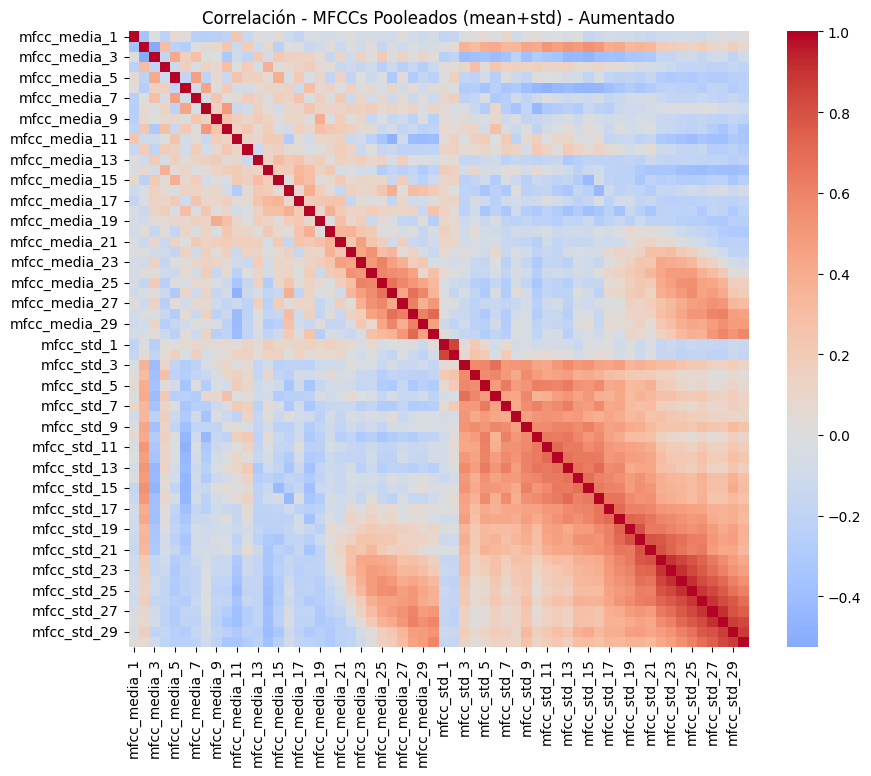

In [60]:
columnas_a_quitar = ['nombre_archivo', 'grupo', 'caja_toracica', 'fold']

X_train = df_train_pool.drop(columns=columnas_a_quitar)

corr_matrix = X_train.corr()

def plot_corr(df, title):
    plt.figure(figsize=(10, 8))
    sns.heatmap(df.corr(), cmap='coolwarm', center=0)
    plt.title(f"Correlación - {title}")
    plt.show()

plot_corr(X_train, "MFCCs Pooleados (mean+std) - Aumentado")

Con esto podemos observar que no hay muchos componentes que estén correlacionados entre sí, excepto por los últimos valores de desviación estándar, los cuales presentan una mayor correlación positiva entre sí. 

En el caso de que observemos valores de correlación elevados entre features, podremos simplemente eliminarlos, ya que aportan información redundante. Si reducimos la dimensionalidad, nuestro modelo se protegerá del sobreaprendizaje y el entrenamiento no será tan costoso.

In [61]:
#Vamos a comprobar la correlación de todas las columnas mfcc_std, y ver si alguna supera cierto umbral
#Este umbral será del 80%, simplemente lo establecemos para ver si alguna de las características supera al menos el 80% de correlación.
columnas_correlacionadas = [f'mfcc_std_{i}' for i in range(1, 31)]
X_correlacionado = X_train[columnas_correlacionadas]

umbral = 0.8
matriz_corr_sub = X_correlacionado.corr()
for i in range(len(matriz_corr_sub.columns)):
    for j in range(i):
        col1 = matriz_corr_sub.columns[i]
        col2 = matriz_corr_sub.columns[j]
        correlacion = matriz_corr_sub.iloc[i, j]
        if(correlacion >= umbral):
            print(f"{col1} y {col2} -> Correlación: {correlacion:.3f}")

mfcc_std_2 y mfcc_std_1 -> Correlación: 0.851
mfcc_std_22 y mfcc_std_21 -> Correlación: 0.802
mfcc_std_23 y mfcc_std_22 -> Correlación: 0.900
mfcc_std_24 y mfcc_std_22 -> Correlación: 0.844
mfcc_std_24 y mfcc_std_23 -> Correlación: 0.909
mfcc_std_25 y mfcc_std_23 -> Correlación: 0.836
mfcc_std_25 y mfcc_std_24 -> Correlación: 0.910
mfcc_std_26 y mfcc_std_24 -> Correlación: 0.824
mfcc_std_26 y mfcc_std_25 -> Correlación: 0.892
mfcc_std_27 y mfcc_std_25 -> Correlación: 0.833
mfcc_std_27 y mfcc_std_26 -> Correlación: 0.903
mfcc_std_28 y mfcc_std_26 -> Correlación: 0.819
mfcc_std_28 y mfcc_std_27 -> Correlación: 0.908
mfcc_std_29 y mfcc_std_27 -> Correlación: 0.801
mfcc_std_29 y mfcc_std_28 -> Correlación: 0.865
mfcc_std_30 y mfcc_std_28 -> Correlación: 0.836
mfcc_std_30 y mfcc_std_29 -> Correlación: 0.876


Con esto podemos ver que hay muchas características que tienen mas del 80% de correlación, sin embargo, muy pocas son las que superan el 85% y solo una pareja supera el 90%.
En este caso, vamos a eliminar aquellas características que superen el 88% de correlación, tratandose de un valor elevado que nos permite reducir la redundancia entre características altamente correlacionadas sin perder información relevante. De este modo, mantenemos la mayor parte de la varianza del espacio original mientras eliminamos únicamente aquellos pares de características que aportan información prácticamente idéntica al modelo.

In [62]:
umbral = 0.88
pares_a_eliminar = set()

matriz_correlacion = X_train.corr()
for i in range(len(matriz_correlacion.columns)):
    for j in range(i):
        if abs(matriz_correlacion.iloc[i, j]) > umbral:
            col1 = matriz_correlacion.columns[i]
            col2 = matriz_correlacion.columns[j]
            correlacion = matriz_correlacion.iloc[i, j]
            print(f"{col1} y {col2} -> Correlación: {correlacion:.3f}")
            
            pares_a_eliminar.add(col1)

print("Columnas a eliminar: ")
print(f"{list(pares_a_eliminar)}. Número total = {len(pares_a_eliminar)}")

#Las eliminamos:
X_pool_reducido_train = df_train_pool.drop(columns = pares_a_eliminar)
X_pool_reducido_test = df_test_pool.drop(columns = pares_a_eliminar)

mfcc_std_23 y mfcc_std_22 -> Correlación: 0.900
mfcc_std_24 y mfcc_std_23 -> Correlación: 0.909
mfcc_std_25 y mfcc_std_24 -> Correlación: 0.910
mfcc_std_26 y mfcc_std_25 -> Correlación: 0.892
mfcc_std_27 y mfcc_std_26 -> Correlación: 0.903
mfcc_std_28 y mfcc_std_27 -> Correlación: 0.908
Columnas a eliminar: 
['mfcc_std_28', 'mfcc_std_23', 'mfcc_std_24', 'mfcc_std_27', 'mfcc_std_25', 'mfcc_std_26']. Número total = 6


In [63]:
X_pool_reducido_train.head()

,nombre_archivo,grupo,caja_toracica,fold,mfcc_media_1,mfcc_media_2,mfcc_media_3,mfcc_media_4,mfcc_media_5,mfcc_media_6,...,mfcc_std_15,mfcc_std_16,mfcc_std_17,mfcc_std_18,mfcc_std_19,mfcc_std_20,mfcc_std_21,mfcc_std_22,mfcc_std_29,mfcc_std_30
0,Nueva grabación 35_chunk000_original.wav,Oxigeno Bajo Flujo,Mixto,1,-395.698486,128.222198,14.744736,22.322180,-2.179186,-0.845055,...,8.078905,8.287786,8.140413,7.223814,7.031062,7.511176,7.103552,6.590400,6.290308,6.236594
1,Nueva grabación 35_chunk000_noise.wav,Oxigeno Bajo Flujo,Mixto,1,-349.742126,82.635704,32.274185,14.441281,2.654882,-2.547759,...,6.944657,7.761823,7.539694,6.780462,6.820736,7.048597,6.781728,6.444450,6.135628,5.955702
2,Nueva grabación 35_chunk000_pitch.wav,Oxigeno Bajo Flujo,Mixto,1,-418.692810,125.661057,12.638054,17.953690,-5.898660,-0.409203,...,8.740746,7.726708,7.640756,8.078579,7.727845,7.607833,6.740335,6.876242,6.572526,6.298136
3,Nueva grabación 35_chunk000_stretch.wav,Oxigeno Bajo Flujo,Mixto,1,-371.298492,112.905205,12.231918,20.830574,-1.896661,0.429245,...,7.918363,8.512820,7.500424,6.700004,6.781082,7.336611,7.273945,6.445484,6.100368,5.932381
4,Nueva grabación 35_chunk001_original.wav,Oxigeno Bajo Flujo,Mixto,1,-428.804565,153.596039,17.333982,19.624706,-11.297787,-2.113888,...,9.049528,8.386795,7.746877,7.247444,7.059894,7.692535,7.388308,7.013628,6.780205,6.246458


In [64]:
X_pool_reducido_test.head()

,nombre_archivo,grupo,caja_toracica,fold,mfcc_media_1,mfcc_media_2,mfcc_media_3,mfcc_media_4,mfcc_media_5,mfcc_media_6,...,mfcc_std_15,mfcc_std_16,mfcc_std_17,mfcc_std_18,mfcc_std_19,mfcc_std_20,mfcc_std_21,mfcc_std_22,mfcc_std_29,mfcc_std_30
0,Asma obesidad grave vni planta_chunk000_origin...,Ventilación Invasiva,Obstructivo,-1,-347.397400,152.618591,-4.039340,15.344688,-7.147709,-0.646219,...,7.605196,7.272064,7.821987,7.489258,7.761950,8.026981,7.296615,7.711065,6.994778,7.767835
1,Asma obesidad grave vni planta_chunk001_origin...,Ventilación Invasiva,Obstructivo,-1,-332.255371,150.329376,-3.941954,21.230312,2.013347,1.089637,...,7.324610,7.708803,7.714882,7.541342,7.457639,7.277525,6.670105,7.070155,6.256960,6.571887
2,Epoc como respira_chunk000_original.wav,Oxigeno Bajo Flujo,Mixto,-1,-358.504883,134.448807,0.406959,16.095858,-2.650892,-0.984858,...,8.725971,9.953801,8.566394,7.991263,7.648769,7.963384,8.086514,7.624754,9.800405,9.690110
3,Nueva grabación 76_chunk000_original.wav,Oxigeno Bajo Flujo,Obstructivo,-1,-366.050720,158.790909,-11.541614,14.498966,-0.010557,-12.866074,...,9.663713,10.773763,8.581945,8.412998,9.595214,8.443714,7.737671,7.865341,7.661318,6.637930
4,Nueva grabación 76_chunk001_original.wav,Oxigeno Bajo Flujo,Obstructivo,-1,-369.023010,180.118164,-6.522512,16.260210,-2.599688,-12.724236,...,9.664102,11.854080,9.160427,9.561007,9.515239,8.416341,7.832856,8.284958,6.356427,6.561510


En este caso, creemos que tenemos un numero bastante reducido de características con el que trabajar, por lo que pasaremos directamente al entrenamiento de modelos.

#### Entrenamiento de Modelos.

In [65]:
columnas_num = [col for col in X_pool_reducido_train.columns if 'mfcc' in col]

X_train_model = X_pool_reducido_train[columnas_num]
X_test_model = X_pool_reducido_test[columnas_num]

y_train_grupo = df_train_pool['grupo']
y_test_grupo = df_test_pool['grupo']

y_train_caja = df_train_pool['caja_toracica']
y_test_caja = df_test_pool['caja_toracica']

folds_oficiales = df_train_pool['fold'].values
ps = PredefinedSplit(test_fold=folds_oficiales)

def evaluar_modelo_pool(grid_grupo, grid_caja, nombre_modelo):    
    print(f"Mejores Hiperparámetros Grupo: {grid_grupo.best_params_}")
    print(f"Mejores Hiperparámetros Caja:  {grid_caja.best_params_}")
    idx_g = grid_grupo.best_index_
    idx_c = grid_caja.best_index_
    acc_g= grid_grupo.cv_results_['mean_test_accuracy'][idx_g]
    f1_mac_g = grid_grupo.cv_results_['mean_test_f1_macro'][idx_g]
    f1_w_g = grid_grupo.cv_results_['mean_test_f1_weighted'][idx_g]
    std_g = grid_grupo.cv_results_['std_test_f1_macro'][idx_g]
    acc_c= grid_caja.cv_results_['mean_test_accuracy'][idx_c]
    f1_mac_c = grid_caja.cv_results_['mean_test_f1_macro'][idx_c]
    f1_w_c= grid_caja.cv_results_['mean_test_f1_weighted'][idx_c]
    std_c = grid_caja.cv_results_['std_test_f1_macro'][idx_c]
    print(f"[CV] Grupo - Acc: {acc_g*100:.2f}% | F1-Macro: {f1_mac_g*100:.2f}% (+/-{std_g*100:.2f}%) | F1-Weighted: {f1_w_g*100:.2f}%")
    print(f"[CV] Caja  - Acc: {acc_c*100:.2f}% | F1-Macro: {f1_mac_c*100:.2f}% (+/-{std_c*100:.2f}%) | F1-Weighted: {f1_w_c*100:.2f}%")
    mlflow.log_metric("grupo_acc_cv", acc_g)
    mlflow.log_metric("grupo_f1_macro_cv", f1_mac_g)
    mlflow.log_metric("grupo_f1_weighted_cv", f1_w_g)
    mlflow.log_metric("caja_acc_cv", acc_c)
    mlflow.log_metric("caja_f1_macro_cv", f1_mac_c)
    mlflow.log_metric("caja_f1_weighted_cv",  f1_w_c)
    for key, value in grid_grupo.best_params_.items():
        mlflow.log_param(f"grupo_best_{key}", value)
    for key, value in grid_caja.best_params_.items():
        mlflow.log_param(f"caja_best_{key}", value)

In [66]:
#Comenzamos con RF: comenzaremos utilizando sus hiperparámetros de base:
#https://scikit-learn.org/stable/modules/generated/sklearn.ensemble.RandomForestClassifier.html
param_grid_rf = {
    'n_estimators': [100],      
    'max_depth': [None],        
    'min_samples_split': [2],   
    'min_samples_leaf': [1],    
    'max_features': ['sqrt'], 
    'bootstrap': [True]         
}

with mlflow.start_run(run_name="RF_Chunking_Diarizado_Aumentado_pool_default"):

    mlflow.set_tag("tipo_dataset", "Chunking_Diarizado_Aumentado_pool") 
    mlflow.set_tag("modelo", "Random Forest")
    mlflow.set_tag("feature_extraction", "Simple")
        
    #Entrenamos para cada objetivo
    rf_base_grupo = RandomForestClassifier(class_weight='balanced', random_state=42)
    grid_rf_grupo = GridSearchCV(rf_base_grupo, param_grid_rf, scoring=scoring_cv, refit='f1_macro', cv=ps, n_jobs=-1)
    grid_rf_grupo.fit(X_train_model, y_train_grupo)
    
    rf_base_caja = RandomForestClassifier(class_weight='balanced', random_state=42)
    grid_rf_caja = GridSearchCV(rf_base_caja, param_grid_rf, scoring=scoring_cv, refit='f1_macro', cv=ps, n_jobs=-1)
    grid_rf_caja.fit(X_train_model, y_train_caja)
    
    evaluar_modelo_pool(grid_rf_grupo, grid_rf_caja, "Random Forest - Pool - Aumentado")

Mejores Hiperparámetros Grupo: {'bootstrap': True, 'max_depth': None, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 100}
Mejores Hiperparámetros Caja:  {'bootstrap': True, 'max_depth': None, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 100}
[CV] Grupo - Acc: 61.89% | F1-Macro: 30.89% (+/-12.57%) | F1-Weighted: 55.11%
[CV] Caja  - Acc: 37.20% | F1-Macro: 22.84% (+/-5.42%) | F1-Weighted: 33.94%


In [67]:
param_grid_rf_1 = {
    'n_estimators': [100, 150],      
    'max_depth': [None, 10, 20],        
    'min_samples_split': [2, 5],   
    'min_samples_leaf': [1, 2],    
    'max_features': ['sqrt'], 
    'bootstrap': [True]         
}

#Entrenamos para cada objetivo
with mlflow.start_run(run_name="RF_Chunking_Diarizado_Aumentado_pool_tune1"):

    mlflow.set_tag("tipo_dataset", "Chunking_Diarizado_Aumentado_pool") 
    mlflow.set_tag("modelo", "Random Forest")
    mlflow.set_tag("feature_extraction", "Simple")
        
    #Entrenamos para cada objetivo
    rf_base_grupo = RandomForestClassifier(class_weight='balanced', random_state=42)
    grid_rf_grupo = GridSearchCV(rf_base_grupo, param_grid_rf_1, scoring=scoring_cv, refit='f1_macro', cv=ps, n_jobs=-1)
    grid_rf_grupo.fit(X_train_model, y_train_grupo)
    
    rf_base_caja = RandomForestClassifier(class_weight='balanced', random_state=42)
    grid_rf_caja = GridSearchCV(rf_base_caja, param_grid_rf_1, scoring=scoring_cv, refit='f1_macro', cv=ps, n_jobs=-1)
    grid_rf_caja.fit(X_train_model, y_train_caja)
    
    evaluar_modelo_pool(grid_rf_grupo, grid_rf_caja, "Random Forest - Pool - Aumentado")

Mejores Hiperparámetros Grupo: {'bootstrap': True, 'max_depth': 10, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'min_samples_split': 5, 'n_estimators': 100}
Mejores Hiperparámetros Caja:  {'bootstrap': True, 'max_depth': 10, 'max_features': 'sqrt', 'min_samples_leaf': 2, 'min_samples_split': 5, 'n_estimators': 100}
[CV] Grupo - Acc: 60.92% | F1-Macro: 31.86% (+/-12.27%) | F1-Weighted: 56.20%
[CV] Caja  - Acc: 39.28% | F1-Macro: 25.50% (+/-6.34%) | F1-Weighted: 37.90%


In [68]:
param_grid_rf_grupo_2 = {
    'n_estimators': [100, 200],      
    'max_depth': [None, 10],        
    'min_samples_split': [5, 7],   
    'min_samples_leaf': [1, 2],    
    'max_features': ['sqrt'], 
    'bootstrap': [True]         
}

param_grid_rf_caja_2 = {
    'n_estimators': [100, 200],      
    'max_depth': [None, 10, 20],        
    'min_samples_split': [5, 7],   
    'min_samples_leaf': [2, 6],    
    'max_features': ['sqrt'], 
    'bootstrap': [True]         
}

#Entrenamos para cada objetivo
with mlflow.start_run(run_name="RF_Chunking_Diarizado_Aumentado_pool_tune2"):

    mlflow.set_tag("tipo_dataset", "Chunking_Diarizado_Aumentado_pool") 
    mlflow.set_tag("modelo", "Random Forest")
    mlflow.set_tag("feature_extraction", "Simple")
        
    #Entrenamos para cada objetivo
    rf_base_grupo = RandomForestClassifier(class_weight='balanced', random_state=42)
    grid_rf_grupo = GridSearchCV(rf_base_grupo, param_grid_rf_grupo_2, scoring=scoring_cv, refit='f1_macro', cv=ps, n_jobs=-1)
    grid_rf_grupo.fit(X_train_model, y_train_grupo)
    
    rf_base_caja = RandomForestClassifier(class_weight='balanced', random_state=42)
    grid_rf_caja = GridSearchCV(rf_base_caja, param_grid_rf_caja_2, scoring=scoring_cv, refit='f1_macro', cv=ps, n_jobs=-1)
    grid_rf_caja.fit(X_train_model, y_train_caja)
    
    evaluar_modelo_pool(grid_rf_grupo, grid_rf_caja, "Random Forest - Pool - Aumentado")

Mejores Hiperparámetros Grupo: {'bootstrap': True, 'max_depth': 10, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'min_samples_split': 5, 'n_estimators': 100}
Mejores Hiperparámetros Caja:  {'bootstrap': True, 'max_depth': 10, 'max_features': 'sqrt', 'min_samples_leaf': 6, 'min_samples_split': 5, 'n_estimators': 100}
[CV] Grupo - Acc: 60.92% | F1-Macro: 31.86% (+/-12.27%) | F1-Weighted: 56.20%
[CV] Caja  - Acc: 38.96% | F1-Macro: 26.09% (+/-5.96%) | F1-Weighted: 38.60%


In [69]:
param_grid_rf_3_grupo_pool = {
    'n_estimators': [100],      
    'max_depth': [10],        
    'min_samples_split': [5, 10],   
    'min_samples_leaf': [1],    
    'max_features': ['sqrt'], 
    'bootstrap': [True]         
}

param_grid_rf_3_caja_pool = {
    'n_estimators': [100],      
    'max_depth': [10],        
    'min_samples_split': [5],   
    'min_samples_leaf': [6, 8],    
    'max_features': ['sqrt'], 
    'bootstrap': [True]         
}


#Entrenamos para cada objetivo
with mlflow.start_run(run_name="RF_Chunking_Diarizado_Aumentado_pool_tune3"):

    mlflow.set_tag("tipo_dataset", "Chunking_Diarizado_Aumentado_pool") 
    mlflow.set_tag("modelo", "Random Forest")
    mlflow.set_tag("feature_extraction", "Simple")
        
    #Entrenamos para cada objetivo
    rf_base_grupo = RandomForestClassifier(class_weight='balanced', random_state=42)
    grid_rf_grupo = GridSearchCV(rf_base_grupo, param_grid_rf_3_grupo_pool, scoring=scoring_cv, refit='f1_macro', cv=ps, n_jobs=-1)
    grid_rf_grupo.fit(X_train_model, y_train_grupo)
    
    rf_base_caja = RandomForestClassifier(class_weight='balanced', random_state=42)
    grid_rf_caja = GridSearchCV(rf_base_caja, param_grid_rf_3_caja_pool, scoring=scoring_cv, refit='f1_macro', cv=ps, n_jobs=-1)
    grid_rf_caja.fit(X_train_model, y_train_caja)
    
    evaluar_modelo_pool(grid_rf_grupo, grid_rf_caja, "Random Forest - Pool - Aumentado")

Mejores Hiperparámetros Grupo: {'bootstrap': True, 'max_depth': 10, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'min_samples_split': 5, 'n_estimators': 100}
Mejores Hiperparámetros Caja:  {'bootstrap': True, 'max_depth': 10, 'max_features': 'sqrt', 'min_samples_leaf': 6, 'min_samples_split': 5, 'n_estimators': 100}
[CV] Grupo - Acc: 60.92% | F1-Macro: 31.86% (+/-12.27%) | F1-Weighted: 56.20%
[CV] Caja  - Acc: 38.96% | F1-Macro: 26.09% (+/-5.96%) | F1-Weighted: 38.60%


In [70]:
param_grid_rf_final_grupo_pool = {
    'n_estimators': [100],      
    'max_depth': [10],        
    'min_samples_split': [5],   
    'min_samples_leaf': [1],    
    'max_features': ['sqrt'], 
    'bootstrap': [True]        
}

param_grid_rf_final_caja_pool = {
    'n_estimators': [100],      
    'max_depth': [10],        
    'min_samples_split': [5],   
    'min_samples_leaf': [6],    
    'max_features': ['sqrt'], 
    'bootstrap': [True]         
}
#Entrenamos para cada objetivo
with mlflow.start_run(run_name="RF_Chunking_Diarizado_Aumentado_pool_tunefinal"):

    mlflow.set_tag("tipo_dataset", "Chunking_Diarizado_Aumentado_pool") 
    mlflow.set_tag("modelo", "Random Forest")
    mlflow.set_tag("feature_extraction", "Simple")
        
    #Entrenamos para cada objetivo
    rf_base_grupo = RandomForestClassifier(class_weight='balanced', random_state=42)
    grid_rf_grupo = GridSearchCV(rf_base_grupo, param_grid_rf_final_grupo_pool, scoring=scoring_cv, refit='f1_macro', cv=ps, n_jobs=-1)
    grid_rf_grupo.fit(X_train_model, y_train_grupo)
    
    rf_base_caja = RandomForestClassifier(class_weight='balanced', random_state=42)
    grid_rf_caja = GridSearchCV(rf_base_caja, param_grid_rf_final_caja_pool, scoring=scoring_cv, refit='f1_macro', cv=ps, n_jobs=-1)
    grid_rf_caja.fit(X_train_model, y_train_caja)
    
    evaluar_modelo_pool(grid_rf_grupo, grid_rf_caja, "Random Forest - Pool - Aumentado")

Mejores Hiperparámetros Grupo: {'bootstrap': True, 'max_depth': 10, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'min_samples_split': 5, 'n_estimators': 100}
Mejores Hiperparámetros Caja:  {'bootstrap': True, 'max_depth': 10, 'max_features': 'sqrt', 'min_samples_leaf': 6, 'min_samples_split': 5, 'n_estimators': 100}
[CV] Grupo - Acc: 60.92% | F1-Macro: 31.86% (+/-12.27%) | F1-Weighted: 56.20%
[CV] Caja  - Acc: 38.96% | F1-Macro: 26.09% (+/-5.96%) | F1-Weighted: 38.60%


#### SVM

In [71]:
param_grid_svm = {
    'C': [1.0],
    'kernel': ['rbf'],
    'gamma': ['scale']
}

with mlflow.start_run(run_name="SVM_Chunking_Diarizado_Aumentado_pool_default"):

    mlflow.set_tag("tipo_dataset", "Chunking_Diarizado_Aumentado_pool") 
    mlflow.set_tag("modelo", "SVM")
    mlflow.set_tag("feature_extraction", "Simple")
        
    #Entrenamos para cada objetivo
    svm_base_grupo = SVC(class_weight='balanced', random_state=42)
    grid_svm_grupo = GridSearchCV(svm_base_grupo, param_grid_svm, scoring=scoring_cv, refit='f1_macro', cv=ps, n_jobs=-1)
    grid_svm_grupo.fit(X_train_model, y_train_grupo)
    
    svm_base_caja = SVC(class_weight='balanced', random_state=42)
    grid_svm_caja = GridSearchCV(svm_base_caja, param_grid_svm, scoring=scoring_cv, refit='f1_macro', cv=ps, n_jobs=-1)
    grid_svm_caja.fit(X_train_model, y_train_caja)
    
    evaluar_modelo_pool(grid_svm_grupo, grid_svm_caja, "SVM - Pool - Aumentado")
    


Mejores Hiperparámetros Grupo: {'C': 1.0, 'gamma': 'scale', 'kernel': 'rbf'}
Mejores Hiperparámetros Caja:  {'C': 1.0, 'gamma': 'scale', 'kernel': 'rbf'}
[CV] Grupo - Acc: 24.90% | F1-Macro: 13.22% (+/-1.81%) | F1-Weighted: 30.64%
[CV] Caja  - Acc: 34.78% | F1-Macro: 18.68% (+/-4.91%) | F1-Weighted: 39.48%


In [72]:
param_grid_svm_1 = {
    'C': [0.5, 1.0, 1.5],
    'kernel': ['rbf'],
    'gamma': ['scale']
}

with mlflow.start_run(run_name="SVM_Chunking_Diarizado_Aumentado_pool_tune1"):

    mlflow.set_tag("tipo_dataset", "Chunking_Diarizado_Aumentado_pool") 
    mlflow.set_tag("modelo", "SVM")
    mlflow.set_tag("feature_extraction", "Simple")
        
    #Entrenamos para cada objetivo
    svm_base_grupo = SVC(class_weight='balanced', random_state=42)
    grid_svm_grupo = GridSearchCV(svm_base_grupo, param_grid_svm_1, scoring=scoring_cv, refit='f1_macro', cv=ps, n_jobs=-1)
    grid_svm_grupo.fit(X_train_model, y_train_grupo)
    
    svm_base_caja = SVC(class_weight='balanced', random_state=42)
    grid_svm_caja = GridSearchCV(svm_base_caja, param_grid_svm_1, scoring=scoring_cv, refit='f1_macro', cv=ps, n_jobs=-1)
    grid_svm_caja.fit(X_train_model, y_train_caja)
    
    evaluar_modelo_pool(grid_svm_grupo, grid_svm_caja, "SVM - Pool - Aumentado")

Mejores Hiperparámetros Grupo: {'C': 1.5, 'gamma': 'scale', 'kernel': 'rbf'}
Mejores Hiperparámetros Caja:  {'C': 0.5, 'gamma': 'scale', 'kernel': 'rbf'}
[CV] Grupo - Acc: 25.64% | F1-Macro: 13.31% (+/-1.96%) | F1-Weighted: 30.83%
[CV] Caja  - Acc: 35.96% | F1-Macro: 18.93% (+/-5.25%) | F1-Weighted: 39.90%


In [74]:
param_grid_svm_2 = {
    'C': [0.5, 1.5, 2.0, 2.5],
    'kernel': ['rbf'],
    'gamma': ['scale']
}

with mlflow.start_run(run_name="SVM_Chunking_Diarizado_Aumentado_pool_tune2"):

    mlflow.set_tag("tipo_dataset", "Chunking_Diarizado_Aumentado_pool") 
    mlflow.set_tag("modelo", "SVM")
    mlflow.set_tag("feature_extraction", "Simple")
        
    #Entrenamos para cada objetivo
    svm_base_grupo = SVC(class_weight='balanced', random_state=42)
    grid_svm_grupo = GridSearchCV(svm_base_grupo, param_grid_svm_2, scoring=scoring_cv, refit='f1_macro', cv=ps, n_jobs=-1)
    grid_svm_grupo.fit(X_train_model, y_train_grupo)
    
    svm_base_caja = SVC(class_weight='balanced', random_state=42)
    grid_svm_caja = GridSearchCV(svm_base_caja, param_grid_svm_2, scoring=scoring_cv, refit='f1_macro', cv=ps, n_jobs=-1)
    grid_svm_caja.fit(X_train_model, y_train_caja)
    
    evaluar_modelo_pool(grid_svm_grupo, grid_svm_caja, "SVM - Pool - Aumentado")

Mejores Hiperparámetros Grupo: {'C': 2.5, 'gamma': 'scale', 'kernel': 'rbf'}
Mejores Hiperparámetros Caja:  {'C': 0.5, 'gamma': 'scale', 'kernel': 'rbf'}
[CV] Grupo - Acc: 28.98% | F1-Macro: 14.52% (+/-2.89%) | F1-Weighted: 33.89%
[CV] Caja  - Acc: 35.96% | F1-Macro: 18.93% (+/-5.25%) | F1-Weighted: 39.90%


In [75]:
param_grid_svm_final_grupo = {
    'C': [2.5],
    'kernel': ['rbf'],
    'gamma': ['scale']
}
param_grid_svm_final_caja = {
    'C': [0.5],
    'kernel': ['rbf'],
    'gamma': ['scale']
}

with mlflow.start_run(run_name="SVM_Chunking_Diarizado_Aumentado_pool_tunefinal"):

    mlflow.set_tag("tipo_dataset", "Chunking_Diarizado_Aumentado_pool") 
    mlflow.set_tag("modelo", "SVM")
    mlflow.set_tag("feature_extraction", "Simple")
        
    #Entrenamos para cada objetivo
    svm_base_grupo = SVC(class_weight='balanced', random_state=42)
    grid_svm_grupo = GridSearchCV(svm_base_grupo, param_grid_svm_final_grupo, scoring=scoring_cv, refit='f1_macro', cv=ps, n_jobs=-1)
    grid_svm_grupo.fit(X_train_model, y_train_grupo)
    
    svm_base_caja = SVC(class_weight='balanced', random_state=42)
    grid_svm_caja = GridSearchCV(svm_base_caja, param_grid_svm_final_caja, scoring=scoring_cv, refit='f1_macro', cv=ps, n_jobs=-1)
    grid_svm_caja.fit(X_train_model, y_train_caja)
    
    evaluar_modelo_pool(grid_svm_grupo, grid_svm_caja, "SVM - Pool - Aumentado")

Mejores Hiperparámetros Grupo: {'C': 2.5, 'gamma': 'scale', 'kernel': 'rbf'}
Mejores Hiperparámetros Caja:  {'C': 0.5, 'gamma': 'scale', 'kernel': 'rbf'}
[CV] Grupo - Acc: 28.98% | F1-Macro: 14.52% (+/-2.89%) | F1-Weighted: 33.89%
[CV] Caja  - Acc: 35.96% | F1-Macro: 18.93% (+/-5.25%) | F1-Weighted: 39.90%


#### LigthGBM

In [76]:
# Parámetros por defecto de LGBMClassifier:
# https://lightgbm.readthedocs.io/en/latest/pythonapi/lightgbm.LGBMClassifier.html
param_grid_lgbm = {
    'n_estimators': [100],
    'learning_rate': [0.1],
    'num_leaves': [31],
    'max_depth': [-1],
    'min_child_samples': [20]
}

with mlflow.start_run(run_name="LGB_Chunking_Diarizado_Aumentado_pool_default"):

    mlflow.set_tag("tipo_dataset", "Chunking_Diarizado_Aumentado_pool") 
    mlflow.set_tag("modelo", "LGB")
    mlflow.set_tag("feature_extraction", "Simple")
        
    #Entrenamos para cada objetivo
    lgbm_base_grupo = LGBMClassifier(class_weight='balanced', random_state=42, n_jobs=1, verbose=-1)
    grid_lgbm_grupo = GridSearchCV(lgbm_base_grupo, param_grid_lgbm, scoring=scoring_cv, refit='f1_macro', cv=ps, n_jobs=-1)
    grid_lgbm_grupo.fit(X_train_model, y_train_grupo)
    
    lgbm_base_caja = LGBMClassifier(class_weight='balanced', random_state=42, n_jobs=1, verbose=-1)
    grid_lgbm_caja = GridSearchCV(lgbm_base_caja, param_grid_lgbm, scoring=scoring_cv, refit='f1_macro', cv=ps, n_jobs=-1)
    grid_lgbm_caja.fit(X_train_model, y_train_caja)
    
    evaluar_modelo_pool(grid_lgbm_grupo, grid_lgbm_caja, "LightGBM - Pool - Aumentado")
    


Mejores Hiperparámetros Grupo: {'learning_rate': 0.1, 'max_depth': -1, 'min_child_samples': 20, 'n_estimators': 100, 'num_leaves': 31}
Mejores Hiperparámetros Caja:  {'learning_rate': 0.1, 'max_depth': -1, 'min_child_samples': 20, 'n_estimators': 100, 'num_leaves': 31}
[CV] Grupo - Acc: 56.49% | F1-Macro: 24.16% (+/-4.08%) | F1-Weighted: 55.62%
[CV] Caja  - Acc: 41.44% | F1-Macro: 24.21% (+/-7.71%) | F1-Weighted: 40.48%


In [77]:
param_grid_lgbm_1 = {
    'n_estimators': [100, 200],
    'learning_rate': [0.05, 0.1],
    'num_leaves': [31, 63],
    'max_depth': [-1, 10],
    'min_child_samples': [20, 50]
}

with mlflow.start_run(run_name="LGB_Chunking_Diarizado_Aumentado_pool_tune1"):

    mlflow.set_tag("tipo_dataset", "Chunking_Diarizado_Aumentado_pool") 
    mlflow.set_tag("modelo", "LGB")
    mlflow.set_tag("feature_extraction", "Simple")
        
    #Entrenamos para cada objetivo
    lgbm_base_grupo = LGBMClassifier(class_weight='balanced', random_state=42, n_jobs=1, verbose=-1)
    grid_lgbm_grupo = GridSearchCV(lgbm_base_grupo, param_grid_lgbm_1, scoring=scoring_cv, refit='f1_macro', cv=ps, n_jobs=-1)
    grid_lgbm_grupo.fit(X_train_model, y_train_grupo)
    
    lgbm_base_caja = LGBMClassifier(class_weight='balanced', random_state=42, n_jobs=1, verbose=-1)
    grid_lgbm_caja = GridSearchCV(lgbm_base_caja, param_grid_lgbm_1, scoring=scoring_cv, refit='f1_macro', cv=ps, n_jobs=-1)
    grid_lgbm_caja.fit(X_train_model, y_train_caja)
    
    evaluar_modelo_pool(grid_lgbm_grupo, grid_lgbm_caja, "LightGBM - Pool - Aumentado")

Mejores Hiperparámetros Grupo: {'learning_rate': 0.1, 'max_depth': 10, 'min_child_samples': 20, 'n_estimators': 100, 'num_leaves': 63}
Mejores Hiperparámetros Caja:  {'learning_rate': 0.1, 'max_depth': -1, 'min_child_samples': 50, 'n_estimators': 200, 'num_leaves': 63}
[CV] Grupo - Acc: 56.66% | F1-Macro: 28.04% (+/-8.62%) | F1-Weighted: 55.69%
[CV] Caja  - Acc: 43.44% | F1-Macro: 26.23% (+/-7.97%) | F1-Weighted: 43.51%


In [80]:
param_grid_lgbm_2_pool_grupo = {
    'n_estimators': [100, 250, 300],
    'learning_rate': [0.1, 0.15],
    'num_leaves': [31, 63],
    'max_depth': [-1, 10],
    'min_child_samples': [20]
}

param_grid_lgbm_2_pool_caja = {
    'n_estimators': [200, 300],
    'learning_rate': [0.1, 0.15],
    'num_leaves': [31, 63],
    'max_depth': [-1],
    'min_child_samples': [50]
}

with mlflow.start_run(run_name="LGB_Chunking_Diarizado_Aumentado_pool_tune2"):

    mlflow.set_tag("tipo_dataset", "Chunking_Diarizado_Aumentado_pool") 
    mlflow.set_tag("modelo", "LGB")
    mlflow.set_tag("feature_extraction", "Simple")
        
    #Entrenamos para cada objetivo
    lgbm_base_grupo = LGBMClassifier(class_weight='balanced', random_state=42, n_jobs=1, verbose=-1)
    grid_lgbm_grupo = GridSearchCV(lgbm_base_grupo, param_grid_lgbm_2_pool_grupo, scoring=scoring_cv, refit='f1_macro', cv=ps, n_jobs=-1)
    grid_lgbm_grupo.fit(X_train_model, y_train_grupo)
    
    lgbm_base_caja = LGBMClassifier(class_weight='balanced', random_state=42, n_jobs=1, verbose=-1)
    grid_lgbm_caja = GridSearchCV(lgbm_base_caja, param_grid_lgbm_2_pool_caja, scoring=scoring_cv, refit='f1_macro', cv=ps, n_jobs=-1)
    grid_lgbm_caja.fit(X_train_model, y_train_caja)
    
    evaluar_modelo_pool(grid_lgbm_grupo, grid_lgbm_caja, "LightGBM - Pool - Aumentado")

Mejores Hiperparámetros Grupo: {'learning_rate': 0.1, 'max_depth': 10, 'min_child_samples': 20, 'n_estimators': 100, 'num_leaves': 63}
Mejores Hiperparámetros Caja:  {'learning_rate': 0.1, 'max_depth': -1, 'min_child_samples': 50, 'n_estimators': 200, 'num_leaves': 63}
[CV] Grupo - Acc: 56.66% | F1-Macro: 28.04% (+/-8.62%) | F1-Weighted: 55.69%
[CV] Caja  - Acc: 43.44% | F1-Macro: 26.23% (+/-7.97%) | F1-Weighted: 43.51%


In [81]:
param_grid_lgbm_final_grupo_pool = {
    'n_estimators': [100],
    'learning_rate': [0.1],
    'num_leaves': [63],
    'max_depth': [10],
    'min_child_samples': [20]
}

param_grid_lgbm_final_caja_pool = {
    'n_estimators': [200],
    'learning_rate': [0.1],
    'num_leaves': [63],
    'max_depth': [-1],
    'min_child_samples': [50]
}

with mlflow.start_run(run_name="LGB_Chunking_Diarizado_Aumentado_pool_tunefinal"):

    mlflow.set_tag("tipo_dataset", "Chunking_Diarizado_Aumentado_pool") 
    mlflow.set_tag("modelo", "LGB")
    mlflow.set_tag("feature_extraction", "Simple")
        
    #Entrenamos para cada objetivo
    lgbm_base_grupo = LGBMClassifier(class_weight='balanced', random_state=42, n_jobs=1, verbose=-1)
    grid_lgbm_grupo = GridSearchCV(lgbm_base_grupo, param_grid_lgbm_final_grupo_pool, scoring=scoring_cv, refit='f1_macro', cv=ps, n_jobs=-1)
    grid_lgbm_grupo.fit(X_train_model, y_train_grupo)
    
    lgbm_base_caja = LGBMClassifier(class_weight='balanced', random_state=42, n_jobs=1, verbose=-1)
    grid_lgbm_caja = GridSearchCV(lgbm_base_caja, param_grid_lgbm_final_caja_pool, scoring=scoring_cv, refit='f1_macro', cv=ps, n_jobs=-1)
    grid_lgbm_caja.fit(X_train_model, y_train_caja)
    
    evaluar_modelo_pool(grid_lgbm_grupo, grid_lgbm_caja, "LightGBM - Pool - Aumentado")

Mejores Hiperparámetros Grupo: {'learning_rate': 0.1, 'max_depth': 10, 'min_child_samples': 20, 'n_estimators': 100, 'num_leaves': 63}
Mejores Hiperparámetros Caja:  {'learning_rate': 0.1, 'max_depth': -1, 'min_child_samples': 50, 'n_estimators': 200, 'num_leaves': 63}
[CV] Grupo - Acc: 56.66% | F1-Macro: 28.04% (+/-8.62%) | F1-Weighted: 55.69%
[CV] Caja  - Acc: 43.44% | F1-Macro: 26.23% (+/-7.97%) | F1-Weighted: 43.51%


##### KNN

In [82]:
# Comenzamos con KNN: utilizando sus hiperparámetros de base:
# https://scikit-learn.org/stable/modules/generated/sklearn.neighbors.KNeighborsClassifier.html
param_grid_knn = {
    'n_neighbors': [5],       
    'weights': ['uniform'],   
    'algorithm': ['auto'],    
    'p': [2]                 
}

with mlflow.start_run(run_name="KNN_Chunking_Diarizado_Aumentado_pool_default"):

    mlflow.set_tag("tipo_dataset", "Chunking_Diarizado_Aumentado_pool") 
    mlflow.set_tag("modelo", "KNN")
    mlflow.set_tag("feature_extraction", "Simple")
        
    # Entrenamos para el objetivo de Grupo Clínico
    knn_base_grupo = KNeighborsClassifier()
    grid_knn_grupo = GridSearchCV(knn_base_grupo, param_grid_knn, scoring=scoring_cv, refit='f1_macro', cv=ps, n_jobs=-1)
    grid_knn_grupo.fit(X_train_model, y_train_grupo)
    
    # Entrenamos para el objetivo de Caja Torácica
    knn_base_caja = KNeighborsClassifier()
    grid_knn_caja = GridSearchCV(knn_base_caja, param_grid_knn, scoring=scoring_cv, refit='f1_macro', cv=ps, n_jobs=-1)
    grid_knn_caja.fit(X_train_model, y_train_caja)
    
    # Evaluamos usando tu función personalizada
    evaluar_modelo_pool(grid_knn_grupo, grid_knn_caja, "KNN - Pool - Aumentado")

Mejores Hiperparámetros Grupo: {'algorithm': 'auto', 'n_neighbors': 5, 'p': 2, 'weights': 'uniform'}
Mejores Hiperparámetros Caja:  {'algorithm': 'auto', 'n_neighbors': 5, 'p': 2, 'weights': 'uniform'}
[CV] Grupo - Acc: 57.29% | F1-Macro: 26.54% (+/-5.91%) | F1-Weighted: 57.29%
[CV] Caja  - Acc: 44.18% | F1-Macro: 28.77% (+/-3.09%) | F1-Weighted: 46.05%


In [84]:
param_grid_knn_1_pool = {
    'n_neighbors': [3, 5, 9],   
    'weights': ['uniform', 'distance'],     
    'metric': ['euclidean', 'manhattan'], 
    'algorithm': ['auto']                   
}

with mlflow.start_run(run_name="KNN_Chunking_Diarizado_Aumentado_pool_tune1"):

    mlflow.set_tag("tipo_dataset", "Chunking_Diarizado_Aumentado_pool") 
    mlflow.set_tag("modelo", "KNN")
    mlflow.set_tag("feature_extraction", "Simple")
        
    # Entrenamos para el objetivo de Grupo Clínico
    knn_base_grupo = KNeighborsClassifier()
    grid_knn_grupo = GridSearchCV(knn_base_grupo, param_grid_knn_1_pool, scoring=scoring_cv, refit='f1_macro', cv=ps, n_jobs=-1)
    grid_knn_grupo.fit(X_train_model, y_train_grupo)
    
    # Entrenamos para el objetivo de Caja Torácica
    knn_base_caja = KNeighborsClassifier()
    grid_knn_caja = GridSearchCV(knn_base_caja, param_grid_knn_1_pool, scoring=scoring_cv, refit='f1_macro', cv=ps, n_jobs=-1)
    grid_knn_caja.fit(X_train_model, y_train_caja)
    
    # Evaluamos usando tu función personalizada
    evaluar_modelo_pool(grid_knn_grupo, grid_knn_caja, "KNN - Pool - Aumentado")

Mejores Hiperparámetros Grupo: {'algorithm': 'auto', 'metric': 'manhattan', 'n_neighbors': 9, 'weights': 'uniform'}
Mejores Hiperparámetros Caja:  {'algorithm': 'auto', 'metric': 'manhattan', 'n_neighbors': 9, 'weights': 'uniform'}
[CV] Grupo - Acc: 58.23% | F1-Macro: 29.18% (+/-7.51%) | F1-Weighted: 58.60%
[CV] Caja  - Acc: 46.54% | F1-Macro: 30.48% (+/-8.07%) | F1-Weighted: 48.39%


In [85]:
param_grid_knn_1_pool_cosine = {
    'n_neighbors': [3, 5, 9],   
    'weights': ['uniform', 'distance'],     
    'metric': ['cosine'], 
    'algorithm': ['brute']                   
}

with mlflow.start_run(run_name="KNN_Chunking_Diarizado_Aumentado_pool_tune1_cosine"):

    mlflow.set_tag("tipo_dataset", "Chunking_Diarizado_Aumentado_pool") 
    mlflow.set_tag("modelo", "KNN")
    mlflow.set_tag("feature_extraction", "Simple")
        
    # Entrenamos para el objetivo de Grupo Clínico
    knn_base_grupo = KNeighborsClassifier()
    grid_knn_grupo = GridSearchCV(knn_base_grupo, param_grid_knn_1_pool_cosine, scoring=scoring_cv, refit='f1_macro', cv=ps, n_jobs=-1)
    grid_knn_grupo.fit(X_train_model, y_train_grupo)
    
    # Entrenamos para el objetivo de Caja Torácica
    knn_base_caja = KNeighborsClassifier()
    grid_knn_caja = GridSearchCV(knn_base_caja, param_grid_knn_1_pool_cosine, scoring=scoring_cv, refit='f1_macro', cv=ps, n_jobs=-1)
    grid_knn_caja.fit(X_train_model, y_train_caja)
    
    # Evaluamos usando tu función personalizada
    evaluar_modelo_pool(grid_knn_grupo, grid_knn_caja, "KNN - Pool - Aumentado")

Mejores Hiperparámetros Grupo: {'algorithm': 'brute', 'metric': 'cosine', 'n_neighbors': 9, 'weights': 'uniform'}
Mejores Hiperparámetros Caja:  {'algorithm': 'brute', 'metric': 'cosine', 'n_neighbors': 9, 'weights': 'uniform'}
[CV] Grupo - Acc: 58.14% | F1-Macro: 26.14% (+/-4.50%) | F1-Weighted: 58.23%
[CV] Caja  - Acc: 37.22% | F1-Macro: 25.31% (+/-10.98%) | F1-Weighted: 36.69%


In [86]:
param_grid_knn_2_minkowski_pool = { #De base, la metrica elegida es minkowski. Modificamos el p = potenciador de dicha métrica
    'n_neighbors': [3, 5, 9],   
    'weights': ['uniform', 'distance'],     
    'p': [1, 2, 3],
    'algorithm': ['auto']                   
}


with mlflow.start_run(run_name="KNN_Chunking_Diarizado_Aumentado_pool_tune2_minkowski"):

    mlflow.set_tag("tipo_dataset", "Chunking_Diarizado_Aumentado_pool") 
    mlflow.set_tag("modelo", "KNN")
    mlflow.set_tag("feature_extraction", "Simple")
        
    # Entrenamos para el objetivo de Grupo Clínico
    knn_base_grupo = KNeighborsClassifier()
    grid_knn_grupo = GridSearchCV(knn_base_grupo, param_grid_knn_2_minkowski_pool, scoring=scoring_cv, refit='f1_macro', cv=ps, n_jobs=-1)
    grid_knn_grupo.fit(X_train_model, y_train_grupo)
    
    # Entrenamos para el objetivo de Caja Torácica
    knn_base_caja = KNeighborsClassifier()
    grid_knn_caja = GridSearchCV(knn_base_caja, param_grid_knn_2_minkowski_pool, scoring=scoring_cv, refit='f1_macro', cv=ps, n_jobs=-1)
    grid_knn_caja.fit(X_train_model, y_train_caja)
    
    # Evaluamos usando tu función personalizada
    evaluar_modelo_pool(grid_knn_grupo, grid_knn_caja, "KNN - Pool - Aumentado")

Mejores Hiperparámetros Grupo: {'algorithm': 'auto', 'n_neighbors': 9, 'p': 1, 'weights': 'uniform'}
Mejores Hiperparámetros Caja:  {'algorithm': 'auto', 'n_neighbors': 9, 'p': 1, 'weights': 'uniform'}
[CV] Grupo - Acc: 58.23% | F1-Macro: 29.18% (+/-7.51%) | F1-Weighted: 58.60%
[CV] Caja  - Acc: 46.54% | F1-Macro: 30.48% (+/-8.07%) | F1-Weighted: 48.39%


In [87]:
param_grid_knn_final = {
    'n_neighbors': [9],       
    'weights': ['uniform'],   
    'algorithm': ['auto'],    
    'p': [1]                 
}

# Entrenamos para el objetivo de Grupo Clínico
with mlflow.start_run(run_name="KNN_Chunking_Diarizado_Aumentado_pool_tunefinal"):

    mlflow.set_tag("tipo_dataset", "Chunking_Diarizado_Aumentado_pool") 
    mlflow.set_tag("modelo", "KNN")
    mlflow.set_tag("feature_extraction", "Simple")
        
    # Entrenamos para el objetivo de Grupo Clínico
    knn_base_grupo = KNeighborsClassifier()
    grid_knn_grupo = GridSearchCV(knn_base_grupo, param_grid_knn_final, scoring=scoring_cv, refit='f1_macro', cv=ps, n_jobs=-1)
    grid_knn_grupo.fit(X_train_model, y_train_grupo)
    
    # Entrenamos para el objetivo de Caja Torácica
    knn_base_caja = KNeighborsClassifier()
    grid_knn_caja = GridSearchCV(knn_base_caja, param_grid_knn_final, scoring=scoring_cv, refit='f1_macro', cv=ps, n_jobs=-1)
    grid_knn_caja.fit(X_train_model, y_train_caja)
    
    # Evaluamos usando tu función personalizada
    evaluar_modelo_pool(grid_knn_grupo, grid_knn_caja, "KNN - Pool - Aumentado")

Mejores Hiperparámetros Grupo: {'algorithm': 'auto', 'n_neighbors': 9, 'p': 1, 'weights': 'uniform'}
Mejores Hiperparámetros Caja:  {'algorithm': 'auto', 'n_neighbors': 9, 'p': 1, 'weights': 'uniform'}
[CV] Grupo - Acc: 58.23% | F1-Macro: 29.18% (+/-7.51%) | F1-Weighted: 58.60%
[CV] Caja  - Acc: 46.54% | F1-Macro: 30.48% (+/-8.07%) | F1-Weighted: 48.39%


## Evaluación Final: Test

El rendimiento de los modelos obtenidos en base a este conjunto de datos es inferior al de otros conjuntos de datos, por lo que no haremos test final sobre este conjunto